#I. Data set description

| Variable | Type | Description | Units |
|:---------|:-----|:------------|:------|
| `id_lab` | Character | Laboratory sample identifier | — |
| `id` | Character | Germplasm accession identifier | — |
| `subset` | Integer | Experimental subset identifier | — |
| `no` | Numeric | Sample number | — |
| `requisitioner` | Character | Source or requesting program of the accession | — |
| `tax_name` | Character | Scientific (taxonomic) name of the species | — |
| `functional_group` | Character | Functional group classification | — |
| `n_replicates_nutrition` | Integer | Number of replicates used for nutritional analyses | Replicates |
| `dm_percentage` | Numeric | Dry matter (DM) content | % |
| `ash_dm` | Numeric | Ash content on a dry matter basis | % DM |
| `om_percentage` | Numeric | Organic matter content | % |
| `pc_percentage_dm` | Numeric | Crude protein (CP) content on a dry matter basis | % DM |
| `adf_percentage_dm` | Numeric | Acid detergent fiber (ADF) content on a dry matter basis | % DM |
| `ndf_percentage_dm` | Numeric | Neutral detergent fiber (NDF) content on a dry matter basis | % DM |
| `n_replicates_gas` | Integer | Number of replicates used for gas production measurements | Replicates |
| `ch4_percentage_in_gas_8h` | Numeric | Methane concentration in fermentation gas after 8 h of incubation | % |
| `ch4_percentage_in_gas_24h` | Numeric | Methane concentration in fermentation gas after 24 h of incubation | % |
| `methane_intensity` | Numeric | Methane intensity measured during fermentation | *(units depend on calculation protocol)* |
| `tddm` | Numeric | True dry matter digestibility (TDDM) | % |

# 1.0 Install packages and import libraries

In [1]:
install.packages(c("patchwork", "viridis", "car"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘forecast’, ‘doBy’, ‘pbkrtest’




In [2]:
library(dplyr)
library(ggplot2)
library(patchwork)
library(viridis)
library(car)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite



# 2.0 Data load

In [3]:
url_compiled <- "https://raw.githubusercontent.com/maurope/lmf/main/output/2026_05_22_data_delivery/08_dashboard_june_2026/compiled_dashboard_2026_7_10.csv"
compiled <- read.csv(url_compiled)

url_gas_raw <- "https://raw.githubusercontent.com/maurope/lmf/main/output/2026_06_09_trial_database_curation/gas_clean_complete_subsets_1234_2026_06_09.csv"
gas_raw <- read.csv(url_gas_raw)

In [4]:
#Remove unofficial functional groups
compiled <- compiled %>%
  filter(!functional_group %in% c("Concentrate", "Forage", ""))

In [5]:
head(compiled)

,id_lab,id,subset,no,requisitioner,tax_name,functional_group,n_replicates_nutrition,dm_percentage,ash_dm,om_percentage,pc_percentage_dm,adf_percentage_dm,ndf_percentage_dm,n_replicates_gas,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,F24-3470,CIAT-11194,1,199,Genetic_bank,Stylosanthes hamata,Herbaceous_legumes,2,92.89,9.61,90.39,21.18,30.18,55.94,6,15.17,18.02,46.12,59.25
2,F24-3471,CIAT-11999,1,201,Genetic_bank,Stylosanthes guianensis,Herbaceous_legumes,2,93.50,10.46,89.54,20.09,33.90,61.32,9,12.98,16.25,46.61,58.55
3,F24-3472,CIAT-12318,1,203,Genetic_bank,Stylosanthes hamata,Herbaceous_legumes,2,94.10,11.08,88.92,22.05,29.34,55.26,9,13.99,16.96,52.27,56.88
4,F24-3427,CIAT-1257,1,113,Genetic_bank,Stylosanthes scabra,Herbaceous_legumes,2,92.72,9.52,90.48,17.96,35.90,69.91,9,15.71,17.60,46.32,58.95
5,F24-3473,CIAT-13575,1,205,Genetic_bank,Desmodium incanum,Herbaceous_legumes,2,94.14,11.52,88.48,23.17,44.09,57.61,9,13.60,16.23,42.43,42.85
6,F24-3474,CIAT-13609,1,207,Genetic_bank,Desmodium incanum,Herbaceous_legumes,2,93.40,11.58,88.42,20.01,40.85,58.78,9,13.66,16.31,46.39,38.40


# 3.0 Descriptive stats

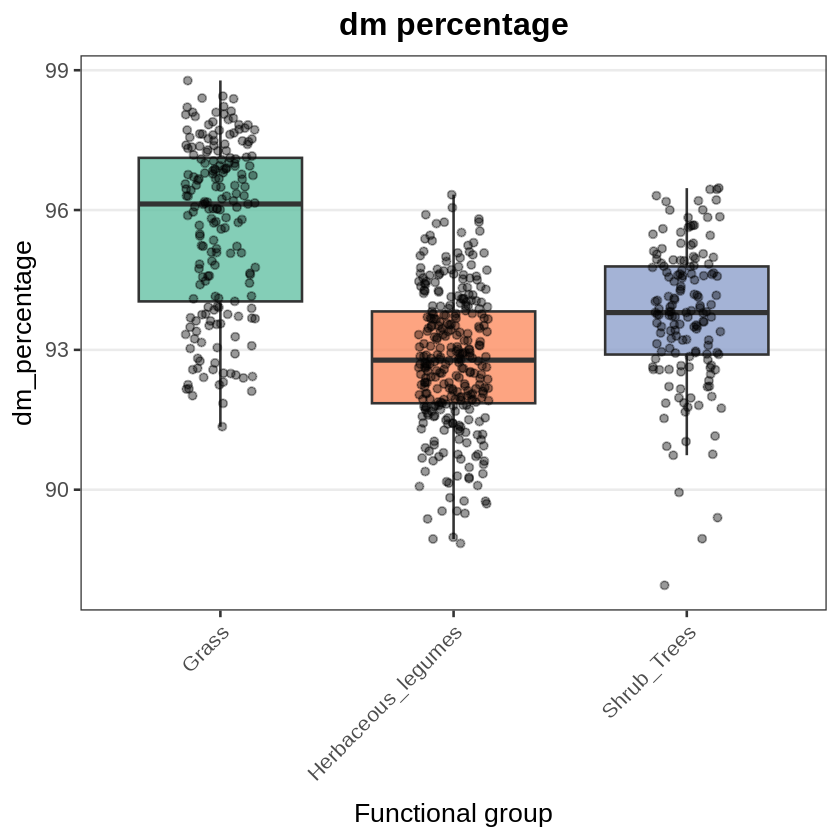

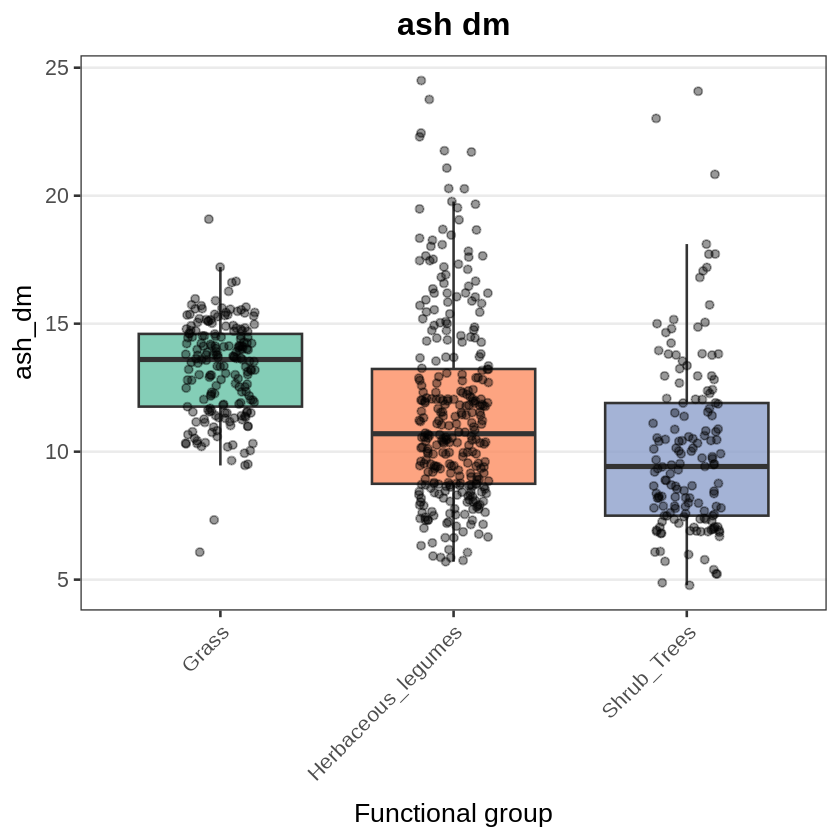

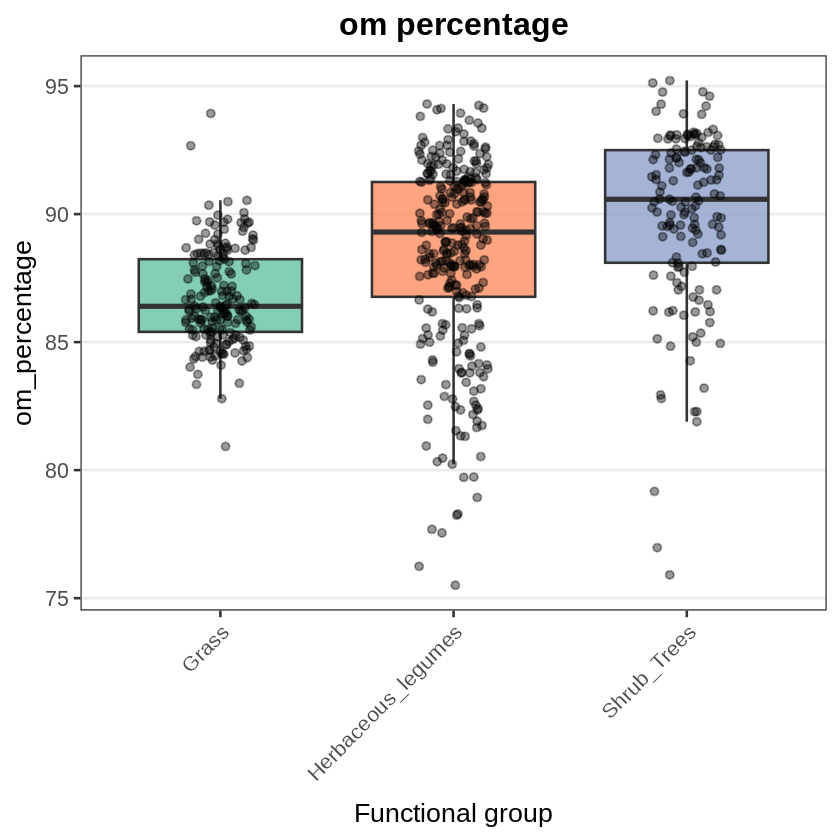

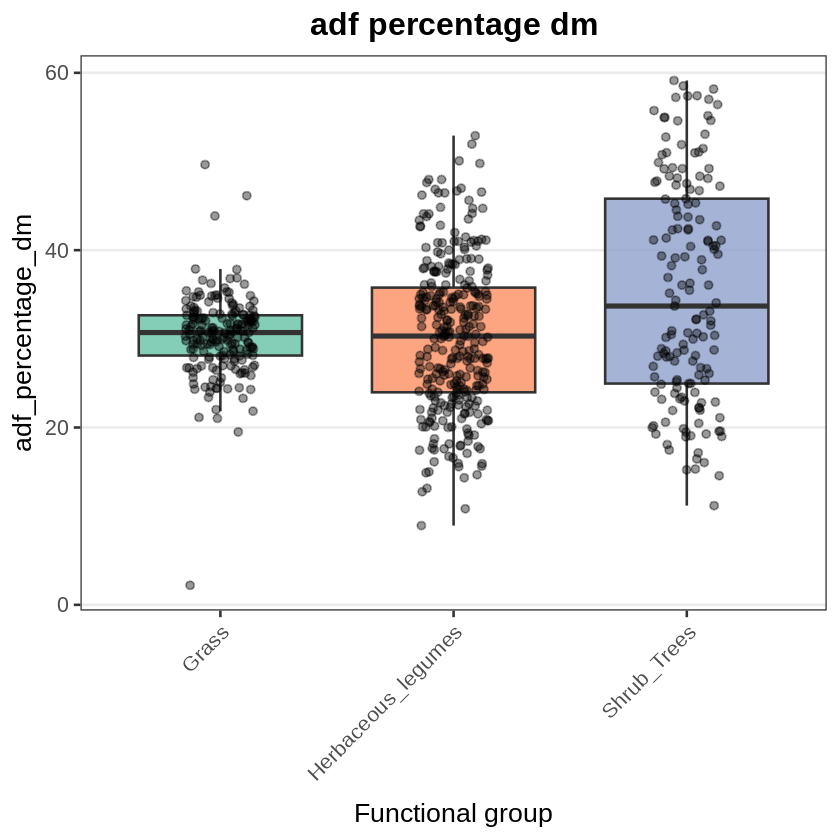

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


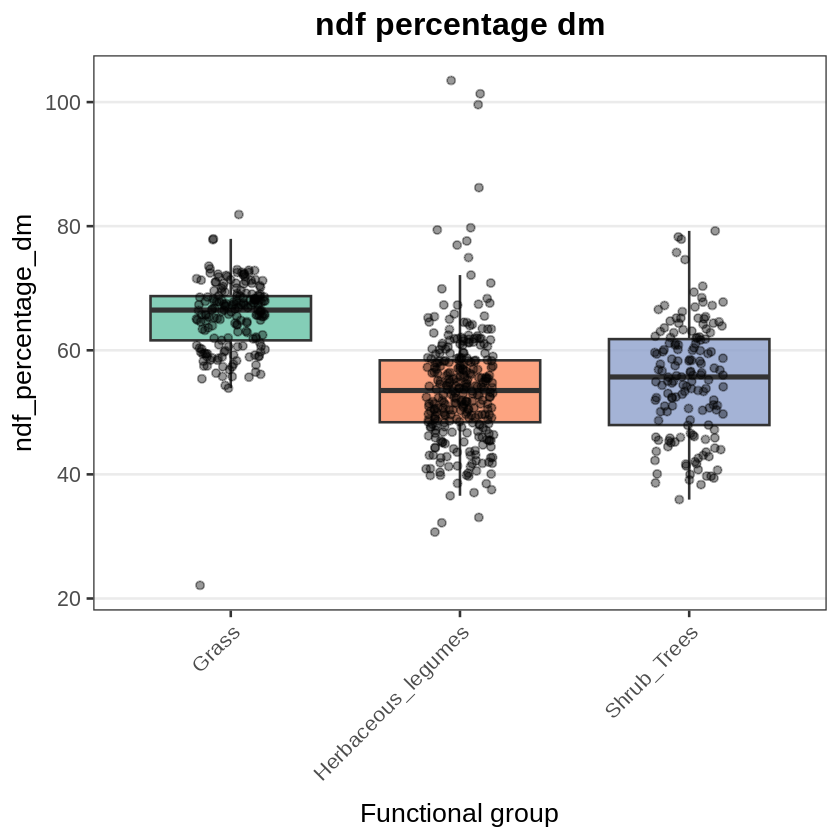

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


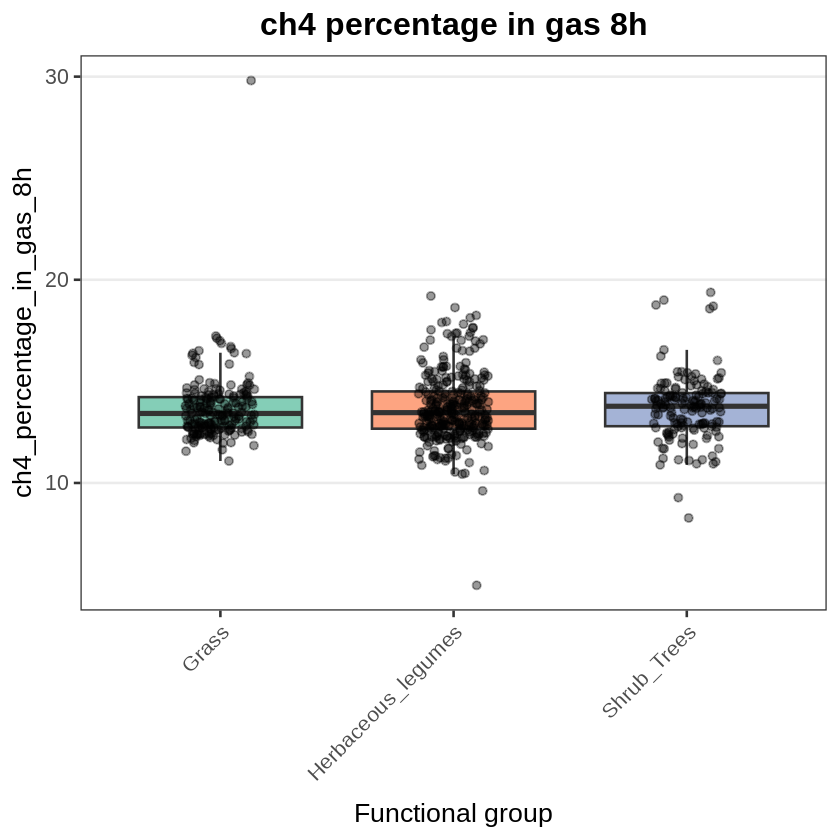

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


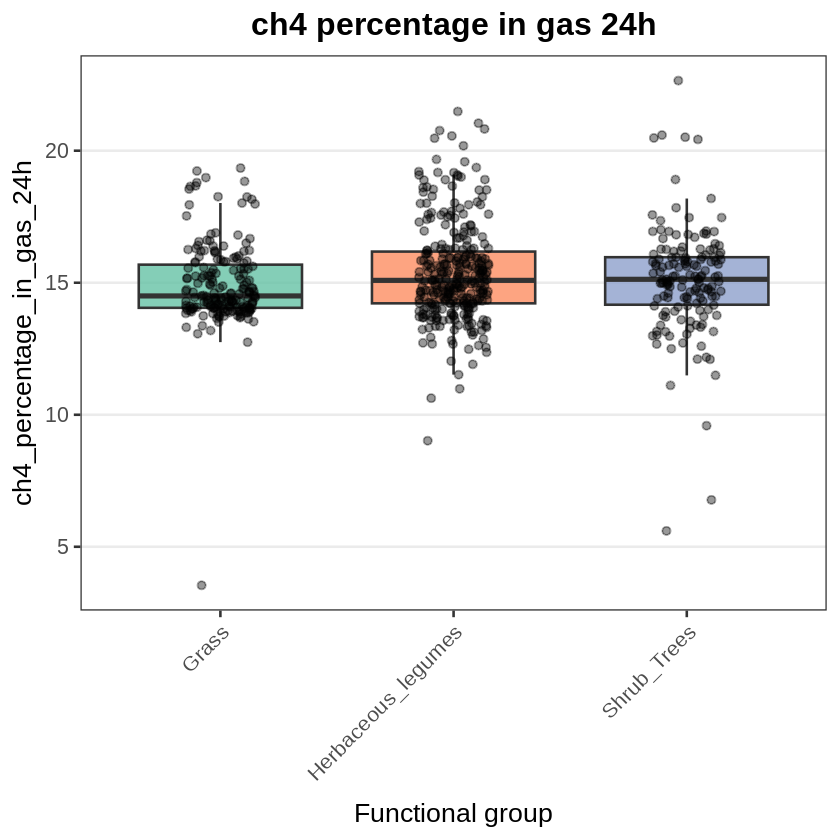

Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”


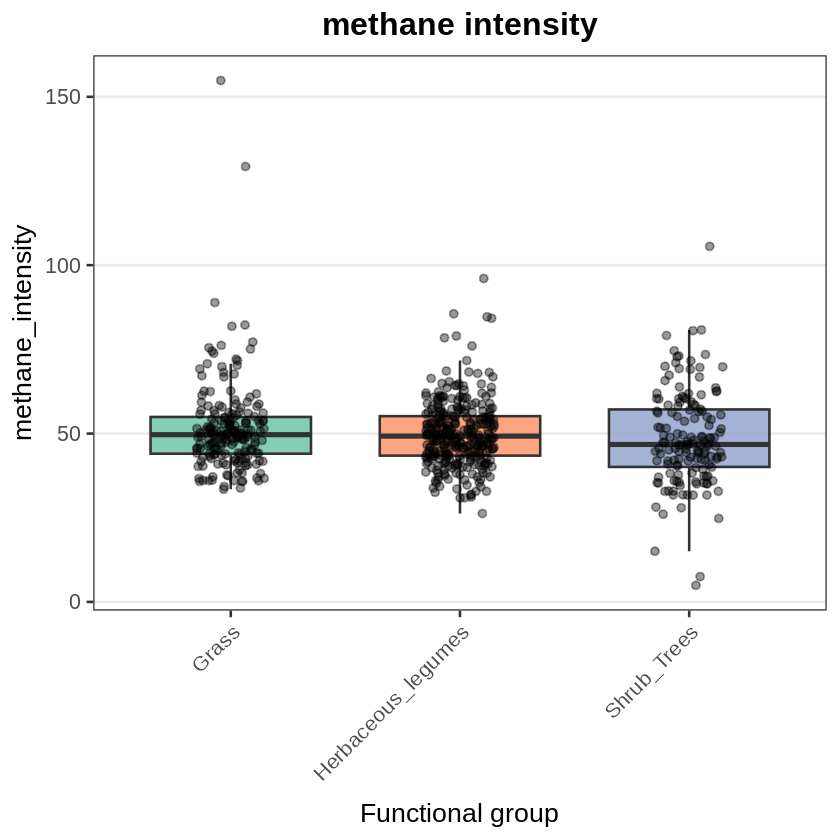

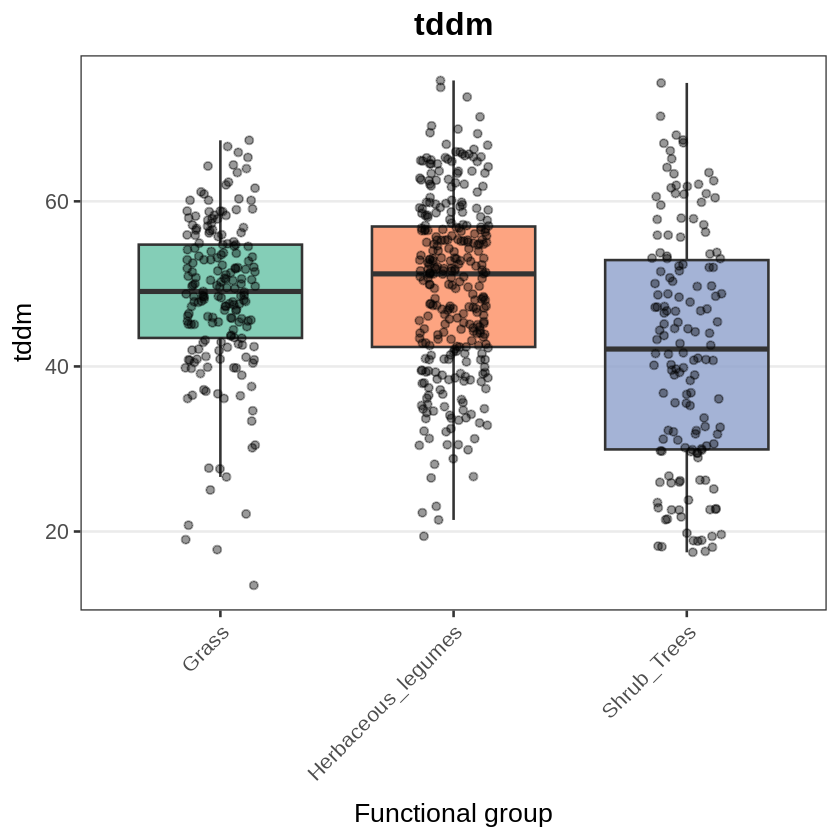

In [6]:
vars <- c(
  "dm_percentage",
  "ash_dm",
  "om_percentage",
  "adf_percentage_dm",
  "ndf_percentage_dm",
  "ch4_percentage_in_gas_8h",
  "ch4_percentage_in_gas_24h",
  "methane_intensity",
  "tddm"
)

for (v in vars) {

  p <- ggplot(compiled, aes(x = functional_group,
                      y = .data[[v]],
                      fill = functional_group)) +
    geom_boxplot(width = 0.7, alpha = 0.8, outlier.shape = NA) +
    geom_jitter(width = 0.15, alpha = 0.4, size = 1.8) +
    scale_fill_brewer(palette = "Set2") +
    labs(
      x = "Functional group",
      y = v,
      title = gsub("_", " ", v)
    ) +
    theme_bw(base_size = 16) +
    theme(
      legend.position = "none",
      plot.title = element_text(face = "bold", hjust = 0.5),
      axis.text.x = element_text(angle = 45, hjust = 1),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank()
    )

  print(p)
}

## 3.1 Stats by functional group

In [7]:
cat('Mean values by functional group')
cat("\n=====================================\n")

compiled %>%
  group_by(functional_group) %>%
  summarise(
    n = n(),
    dm_percentage = mean(dm_percentage, na.rm = TRUE),
    ash_dm = mean(ash_dm, na.rm = TRUE),
    om_percentage = mean(om_percentage, na.rm = TRUE),
    adf_percentage_dm = mean(adf_percentage_dm, na.rm = TRUE),
    ndf_percentage_dm = mean(ndf_percentage_dm, na.rm = TRUE),
    ch4_percentage_in_gas_8h = mean(ch4_percentage_in_gas_8h, na.rm = TRUE),
    ch4_percentage_in_gas_24h = mean(ch4_percentage_in_gas_24h, na.rm = TRUE),
    methane_intensity = mean(methane_intensity, na.rm = TRUE),
    tddm = mean(tddm, na.rm = TRUE),

  )

Mean values by functional group


functional_group,n,dm_percentage,ash_dm,om_percentage,adf_percentage_dm,ndf_percentage_dm,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Grass,193,95.65233,13.23109,86.76886,30.33710,65.42212,13.68246,14.94429,51.61974,48.45246
Herbaceous_legumes,308,92.78344,11.54951,88.45045,30.27140,53.85140,13.69440,15.37560,49.89394,49.79033
Shrub_Trees,153,93.73222,10.07686,89.92294,35.31464,55.16608,13.70127,15.09940,48.57113,41.95287


# 4.0 Evaluation of batch effects using Star grass as a control sample

In [8]:
# Column names
names(gas_raw)

[1] "subset"                    "no"                       
 [3] "requisitioner"             "id_lab"                   
 [5] "id"                        "tax_order"                
 [7] "family"                    "genus"                    
 [9] "species"                   "tax_name"                 
[11] "functional_group"          "set_ciat"                 
[13] "batch"                     "run"                      
[15] "replication"               "syrange"                  
[17] "sample_weight_g"           "undigested_dm_g"          
[19] "dm_incubated"              "digested_feed_mg"         
[21] "net_gas_8h_ml"             "net_gas_24h_ml"           
[23] "ch4_8h_ml"                 "ch4_24h_ml"               
[25] "ch4_percentage_in_gas_8h"  "ch4_percentage_in_gas_24h"
[27] "gas_ml_g_dm_incubated_24h" "part_fact"                
[29] "ch4_ml_g_dm_incubated_24h" "ch4_ml_g_ndf_digested_24h"
[31] "methane_intensity"         "tddm"                     
[33] "information_remarks_1"     "information_remarks_2"    
[35] "gas_remarks_1"             "gas_remarks_2"            
[37] "digest_remarks_1"          "digest_remarks_2"         
[39] "delete"

In [9]:
# Star grass dataframe
star_grass <- gas_raw %>%
  filter(id_lab == "F25-0008")

head(star_grass)

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,⋯,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm,information_remarks_1,information_remarks_2,gas_remarks_1,gas_remarks_2,digest_remarks_1,digest_remarks_2,delete
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>
1,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.101,164.3696,12.53515,,,,NA,,,no
2,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.101,164.3696,12.53515,,"30,31,32",,NA,,,no
3,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.101,164.3696,12.53515,,"33,34,35",,NA,,,no
4,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.101,164.3696,12.53515,,"36,37,38",,NA,,,no
5,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.101,164.3696,12.53515,,"42,43,47",,NA,,,no
6,2,102,LMF,F25-0008,Sample-8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,⋯,-644.101,164.3696,12.53515,,"45,46,47",,NA,,,no


### 4.1 Analyses of variance

In [10]:
# Anova for one variable
cat('Anova for net_gas_8h_ml')
cat("\n==========================\n")
modelo <- lm(net_gas_8h_ml ~ factor(batch), data = star_grass)
anova(modelo)

Anova for net_gas_8h_ml


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
factor(batch),34,3077.207,90.506076,16.52924,9.833227e-61
Residuals,479,2622.772,5.475515,NA,NA


In [11]:
shapiro.test(residuals(modelo))


	Shapiro-Wilk normality test

data:  residuals(modelo)
W = 0.91211, p-value < 2.2e-16


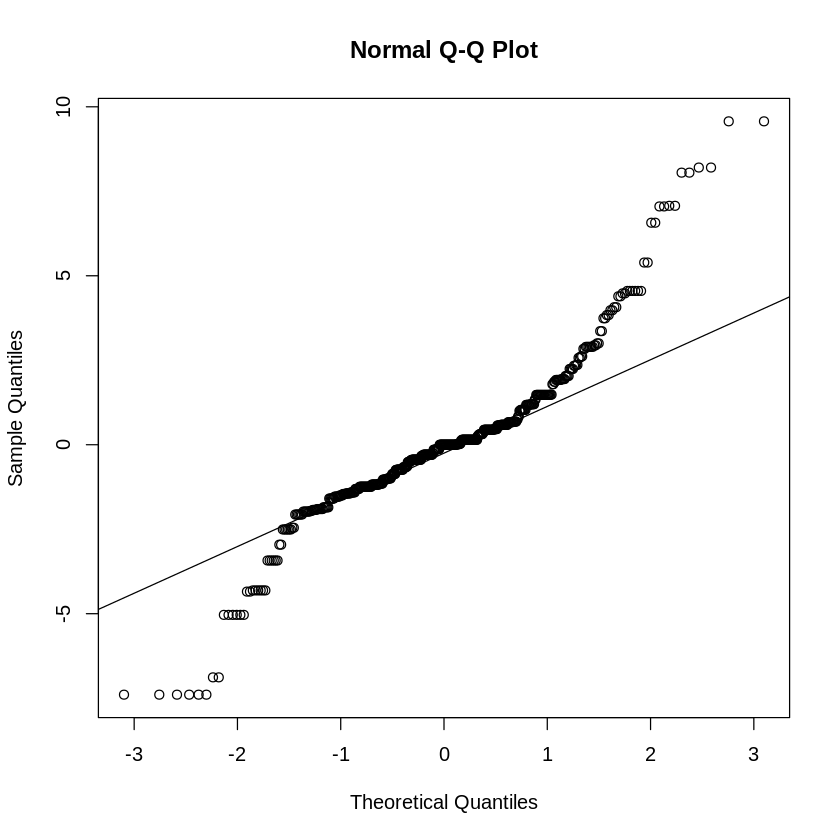

In [12]:
qqnorm(residuals(modelo))
qqline(residuals(modelo))

In [13]:
leveneTest(net_gas_24h_ml ~ factor(batch), data = star_grass)

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,34,4.708212,2.982628e-15
,479,NA,NA


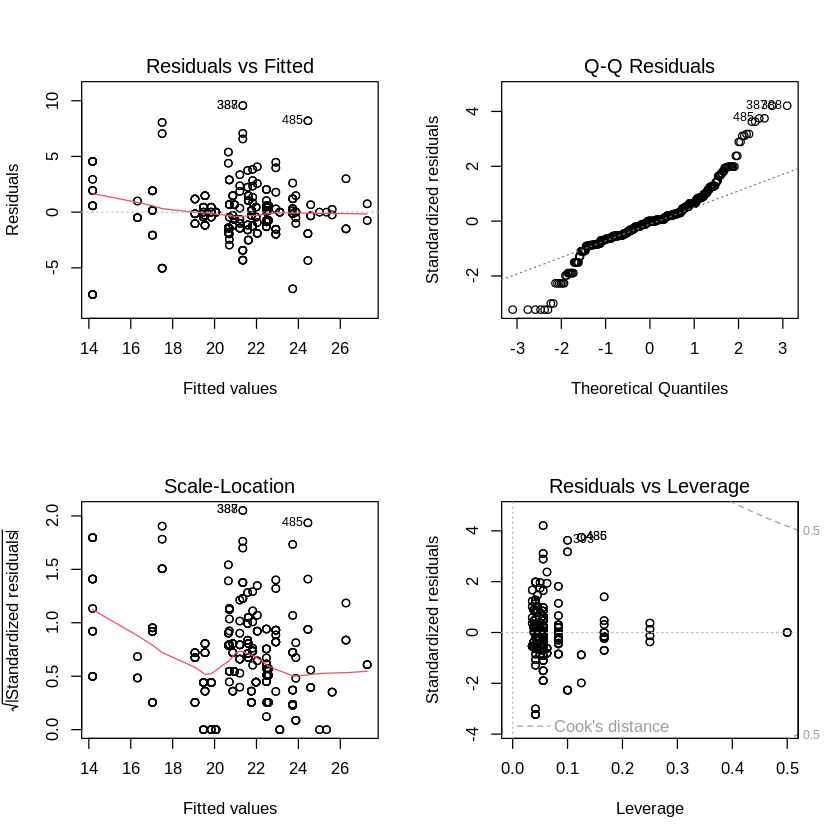

In [14]:
par(mfrow = c(2,2))
plot(modelo)

In [15]:
# Quantitative variables to analyze
variables <-c('undigested_dm_g','dm_incubated','digested_feed_mg','net_gas_8h_ml','net_gas_24h_ml','ch4_8h_ml','ch4_24h_ml',
              'ch4_percentage_in_gas_8h','ch4_percentage_in_gas_24h','gas_ml_g_dm_incubated_24h','part_fact',
              'ch4_ml_g_dm_incubated_24h','ch4_ml_g_ndf_digested_24h','methane_intensity','tddm')

In [16]:
# Anovas for all quantitative variables
for (var in variables) {

  cat("\n=====================================\n")
  cat(var, "\n")
  cat("=====================================\n")

  linear_model <- lm(
    as.formula(paste(var, "~ factor(batch)")),
    data = star_grass
  )

  print(anova(linear_model))
}


undigested_dm_g 
Analysis of Variance Table

Response: undigested_dm_g
               Df  Sum Sq   Mean Sq F value    Pr(>F)    
factor(batch)  34 0.49661 0.0146061  4.6956 3.394e-15 ***
Residuals     479 1.48997 0.0031106                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

dm_incubated 
Analysis of Variance Table

Response: dm_incubated
               Df Sum Sq Mean Sq F value    Pr(>F)    
factor(batch)  34 213567  6281.4  86.931 < 2.2e-16 ***
Residuals     453  32733    72.3                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

digested_feed_mg 
Analysis of Variance Table

Response: digested_feed_mg
               Df Sum Sq Mean Sq F value    Pr(>F)    
factor(batch)  34 527022 15500.7  9.4118 < 2.2e-16 ***
Residuals     453 746064  1646.9                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

net_gas_8h_ml 
Analysis of Variance Table

Response: net_gas_8h_ml
               

In [17]:
# ANOVA statistics for all variables, summarized in a table
anova_results <- data.frame(
  variable = character(),
  F = numeric(),
  p = numeric()
)

for (var in variables) {

  linear_model <- lm(
    as.formula(paste(var, "~ factor(batch)")),
    data = star_grass
  )

  aov_tab <- anova(linear_model)

  anova_results <- rbind(
    anova_results,
    data.frame(
      variable = var,
      F = aov_tab$`F value`[1],
      p = aov_tab$`Pr(>F)`[1]
    )
  )
}

anova_results

variable,F,p
<chr>,<dbl>,<dbl>
undigested_dm_g,4.695607,3.393786e-15
dm_incubated,86.930880,1.274356e-175
digested_feed_mg,9.411794,9.232698e-35
net_gas_8h_ml,16.529235,9.833227e-61
net_gas_24h_ml,17.068783,1.891051e-62
ch4_8h_ml,20.651134,3.309537e-73
ch4_24h_ml,18.286797,3.153712e-66
ch4_percentage_in_gas_8h,22.739635,5.119188e-79
ch4_percentage_in_gas_24h,25.647083,1.293154e-86


### 4.2 Visualization

In [18]:
# Boxplot function
plot_batch_boxplot <- function(data, variable) {

  ggplot(
    data,
    aes(
      x = factor(batch),
      y = .data[[variable]]
    )
  ) +
    geom_boxplot(
      width = 0.7,
      alpha = 0.8,
      outlier.shape = NA
    ) +
    geom_jitter(
      width = 0.15,
      alpha = 0.4,
      size = 2.2
    ) +
    labs(
      x = "Batch",
      y = gsub("_", " ", variable),
      title = paste("Effect of batch on", gsub("_", " ", variable))
    ) +
    theme_bw(base_size = 20) +
    theme(
      legend.position = "none",
      plot.title = element_text(size = 26, face = "bold", hjust = 0.5),
      axis.title = element_text(size = 22, face = "bold"),
      axis.text.x = element_text(size = 18, angle = 45, hjust = 1),
      axis.text.y = element_text(size = 18),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank()
    )
}

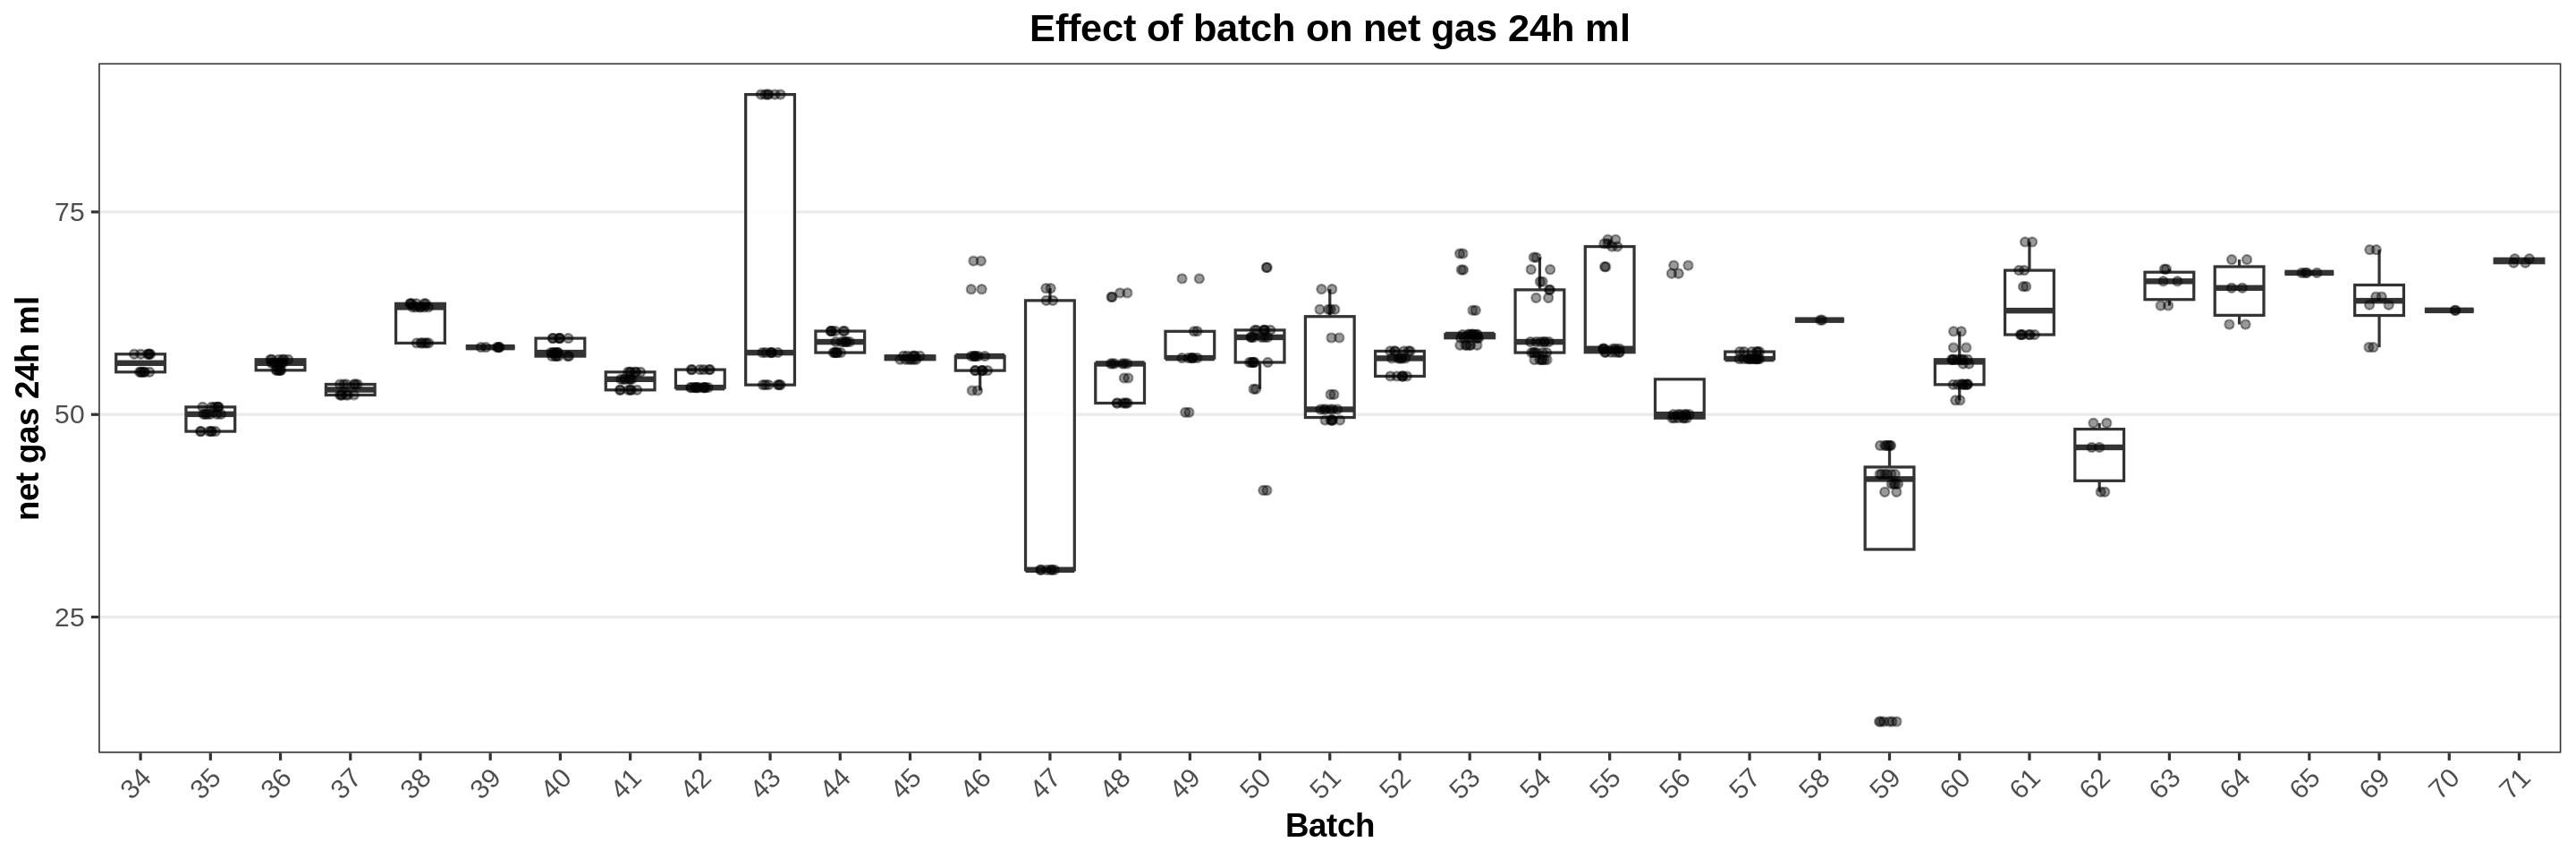

In [19]:
# One variable boxplot
v <- "net_gas_24h_ml"
options(repr.plot.width = 24, repr.plot.height = 8)
plot_batch_boxplot(star_grass, v)

Warning message:
“Removed 26 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 26 rows containing missing values or values outside the scale range
(`geom_point()`).”


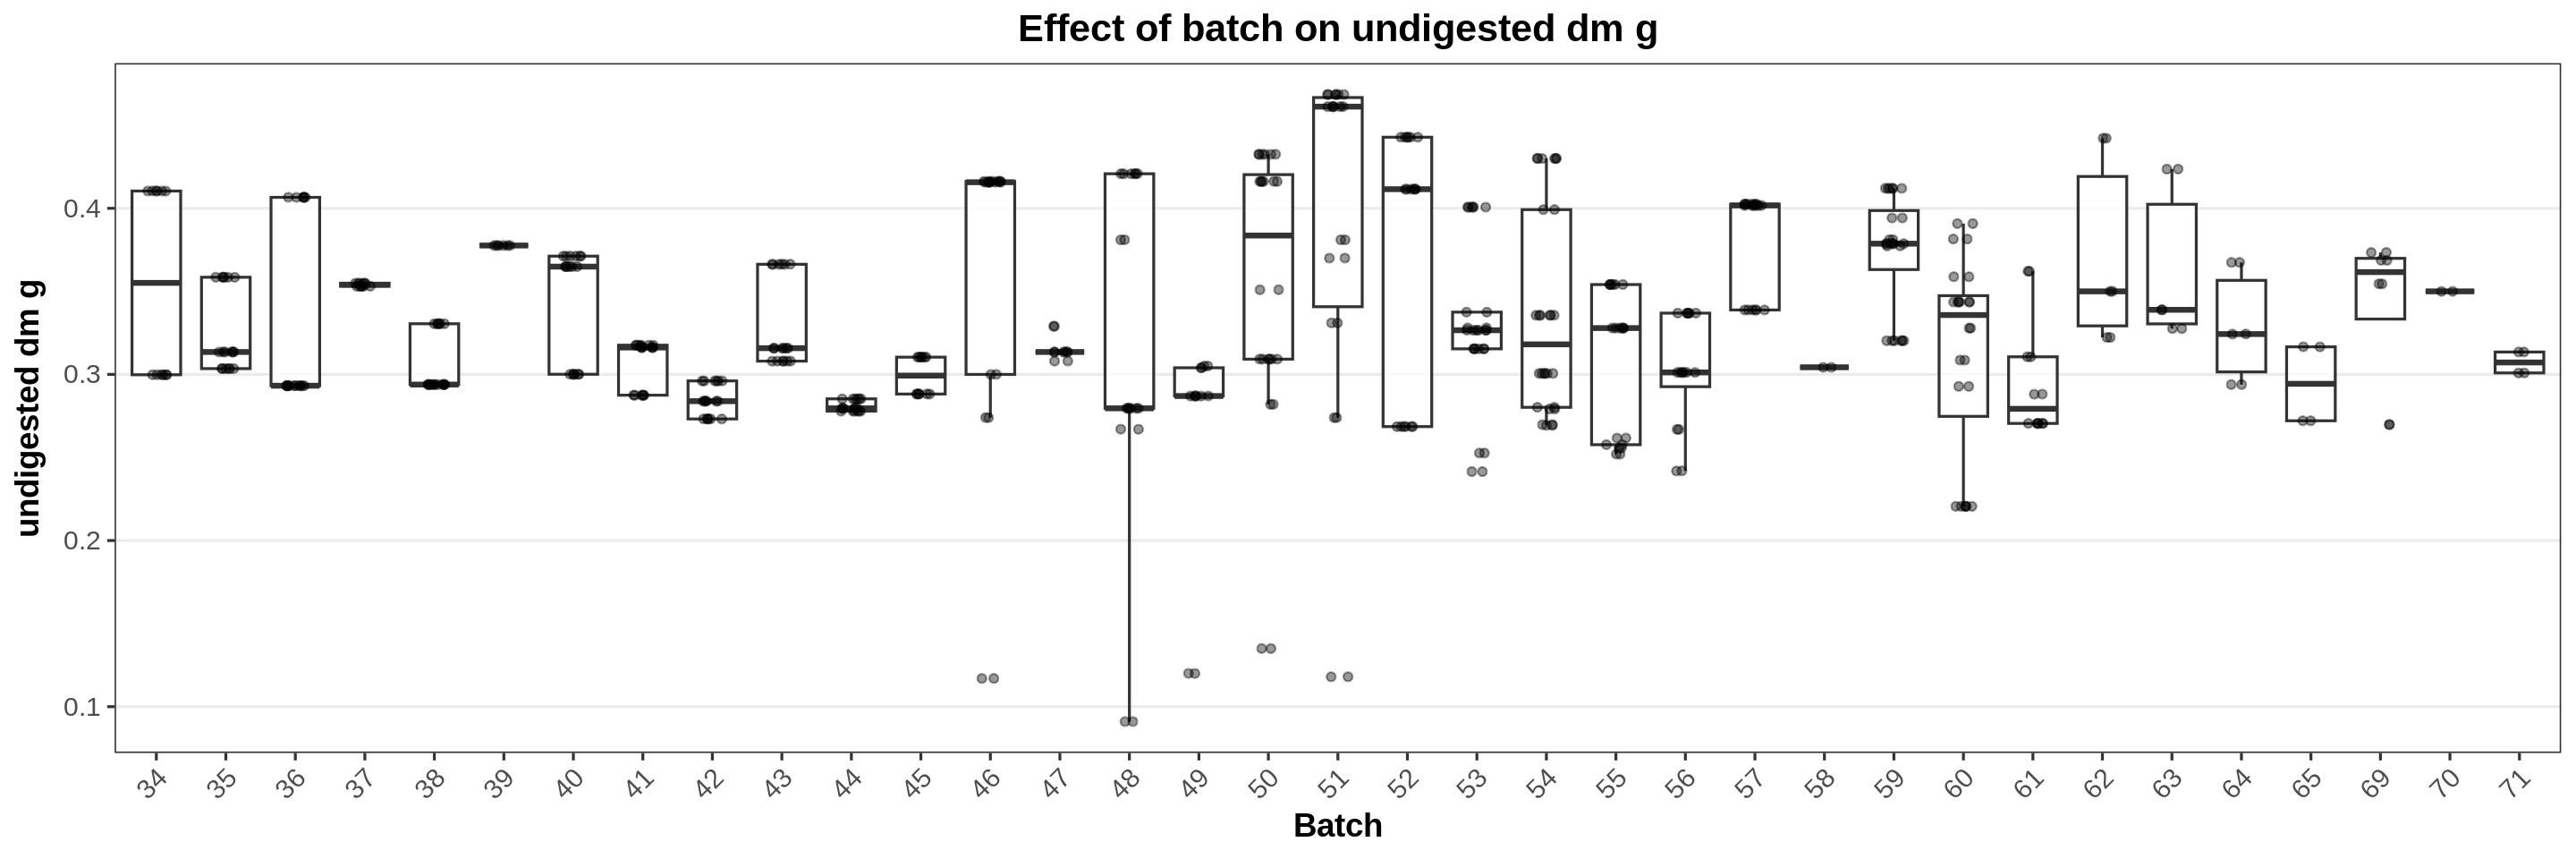

Warning message:
“Removed 26 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 26 rows containing missing values or values outside the scale range
(`geom_point()`).”


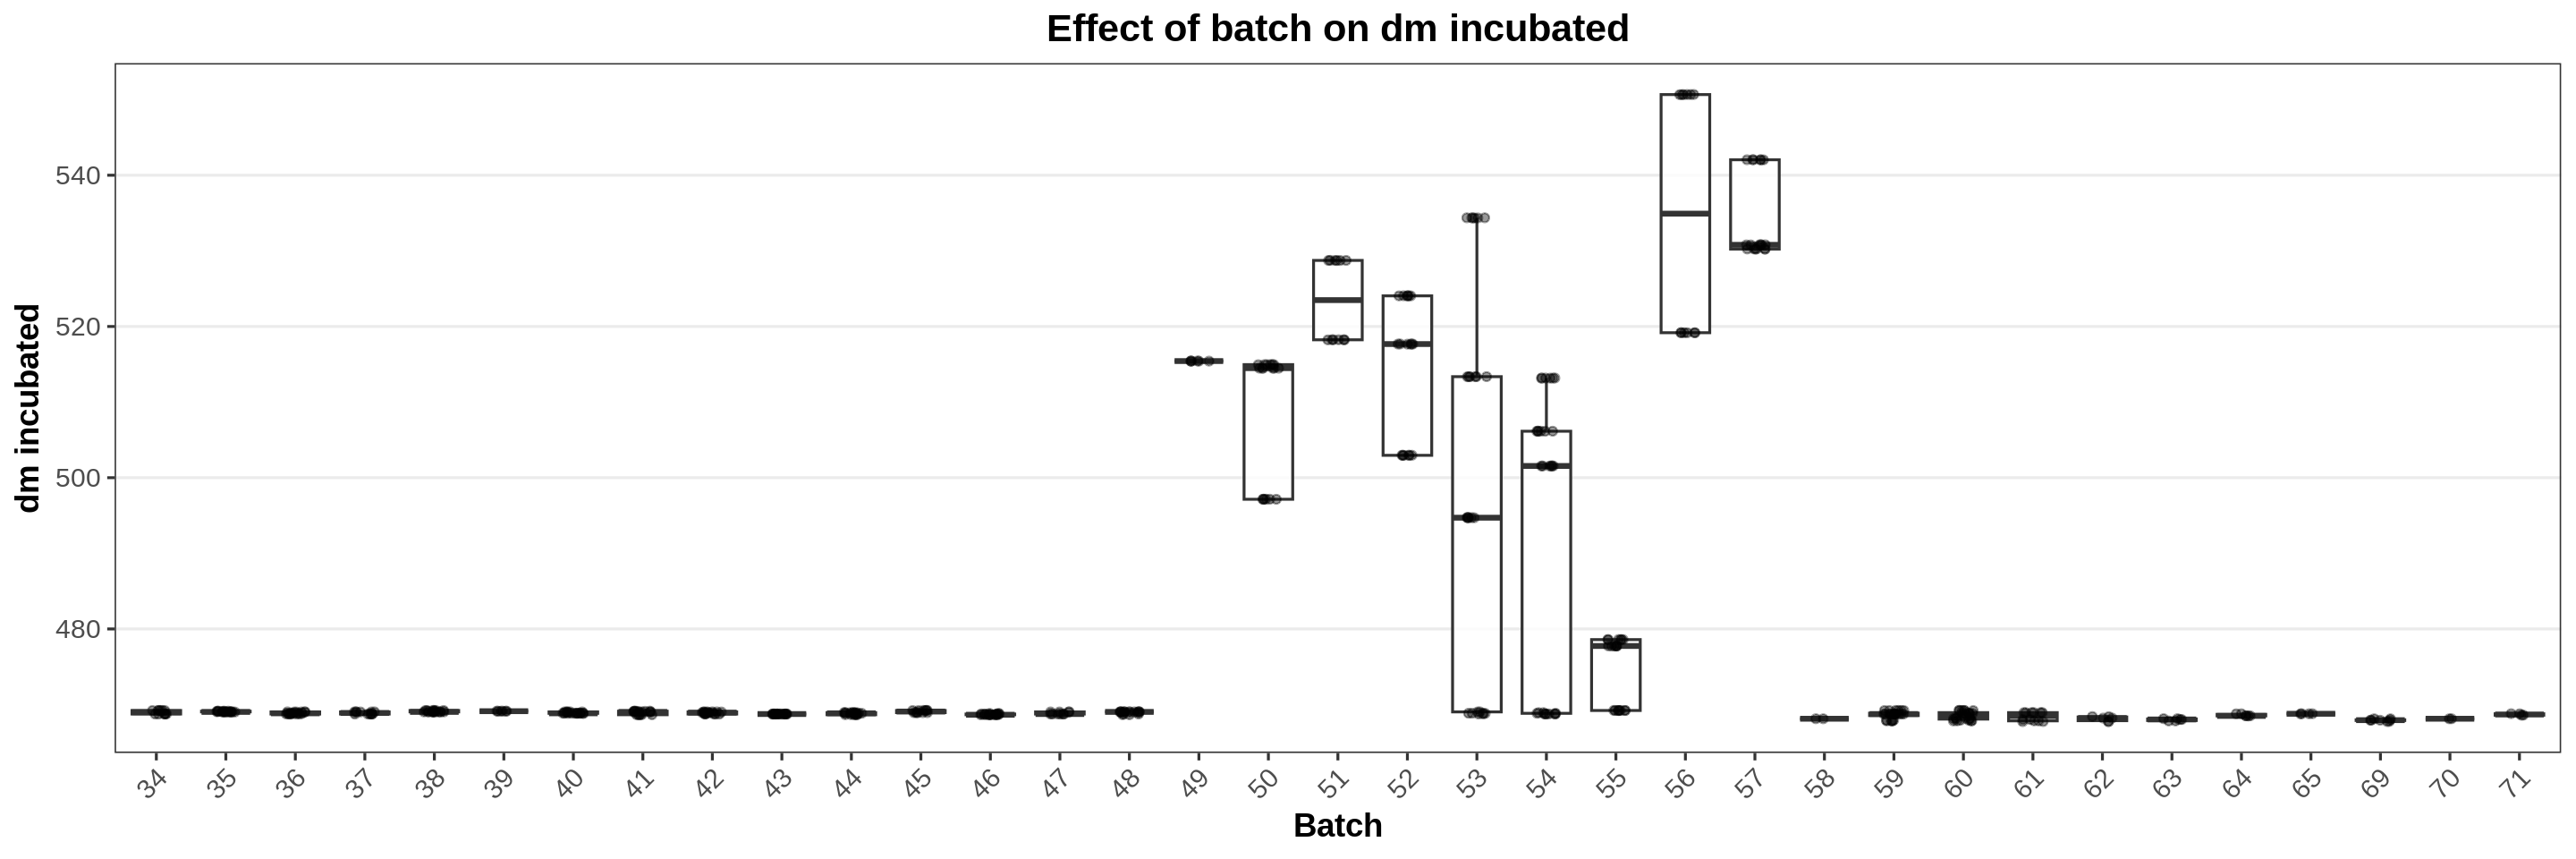

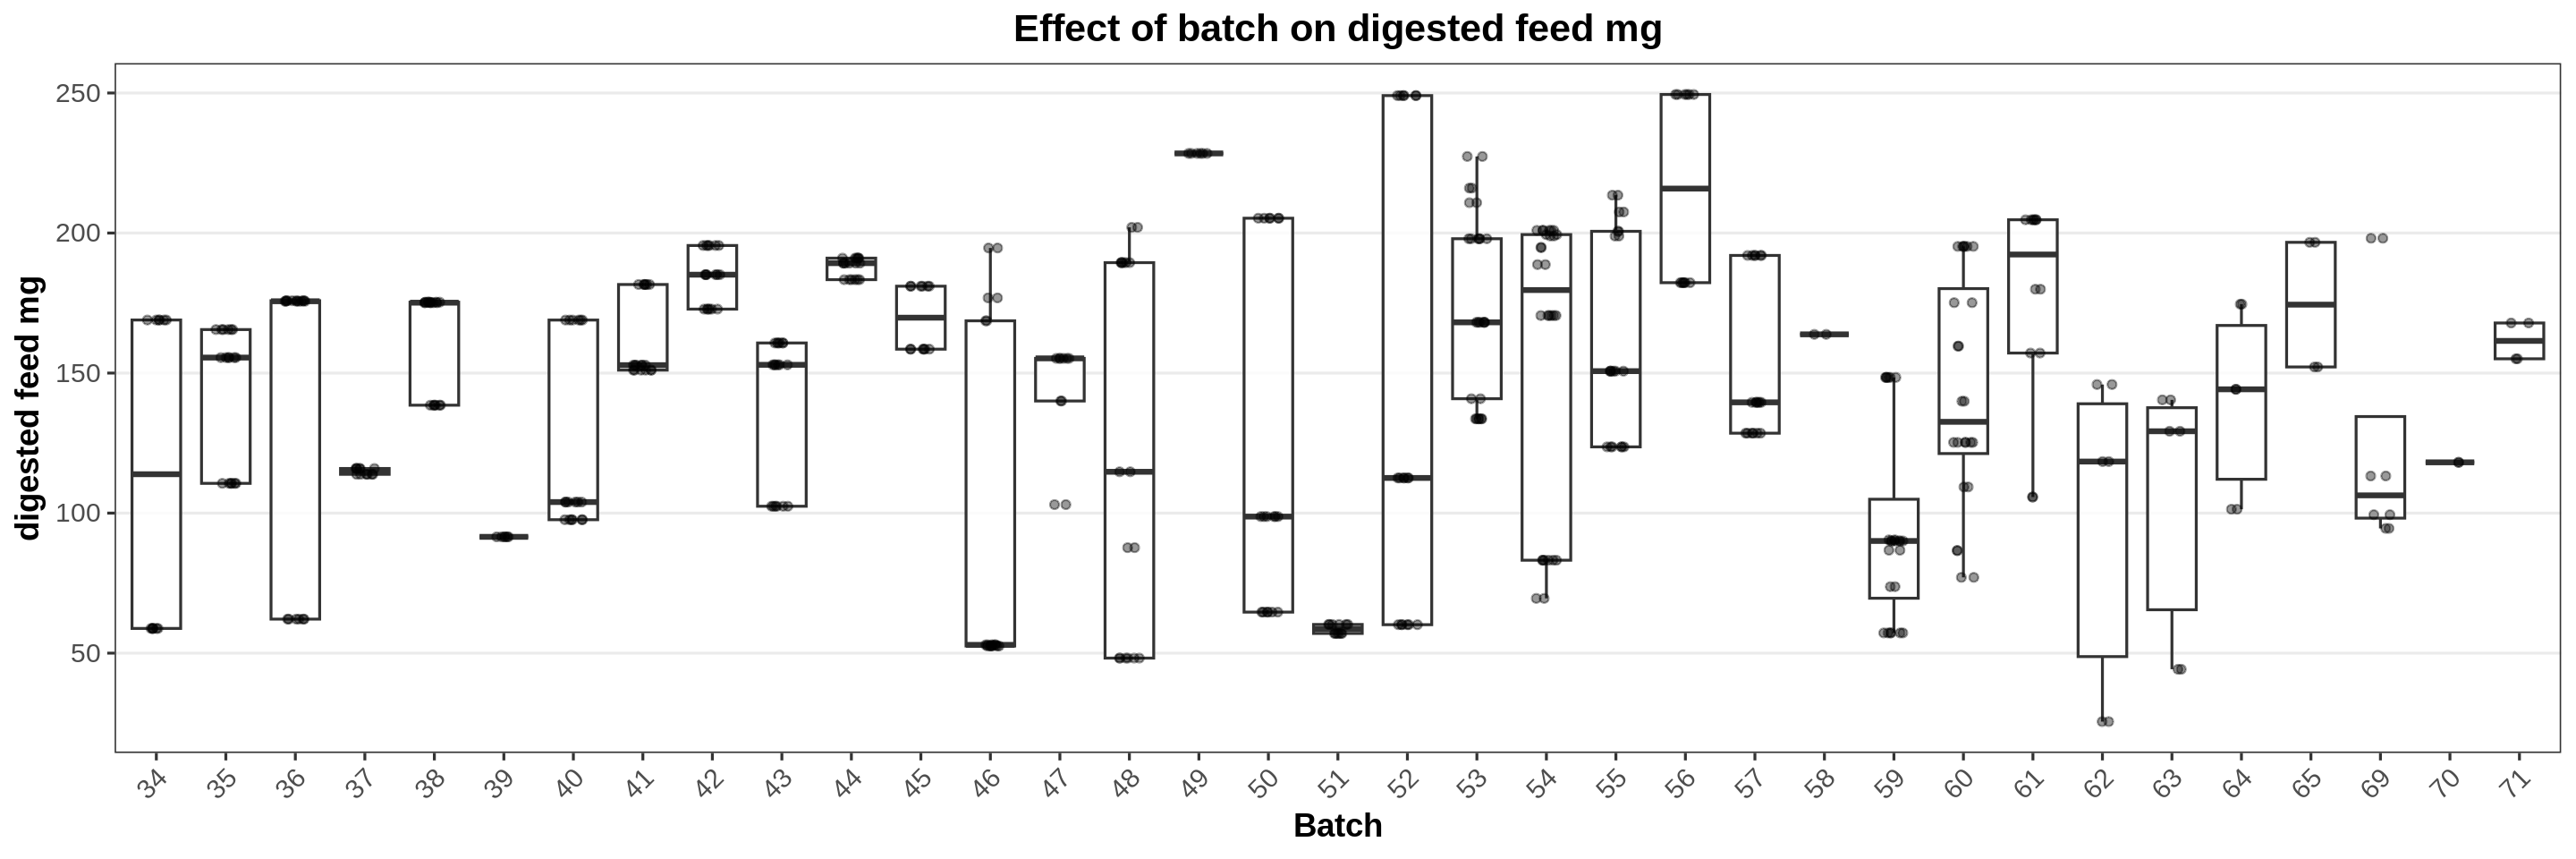

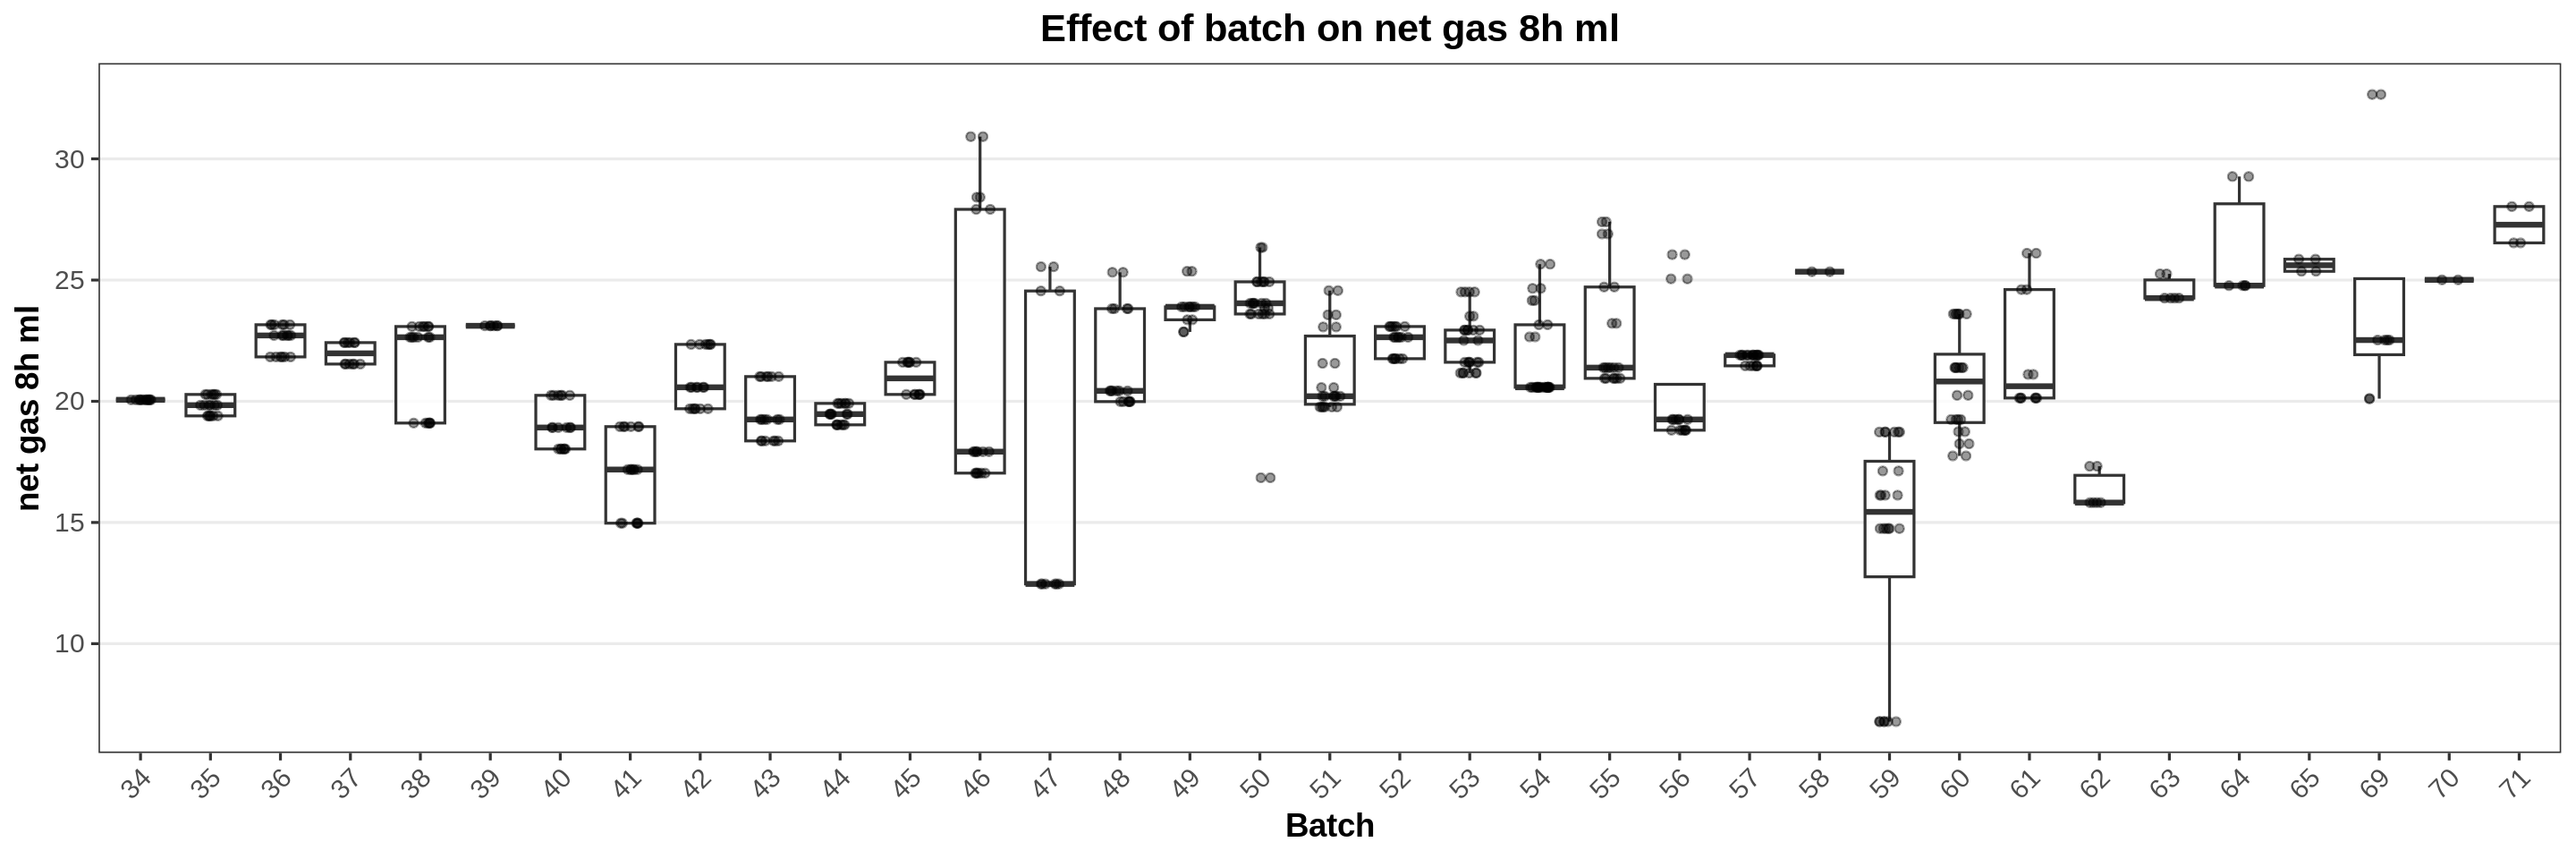

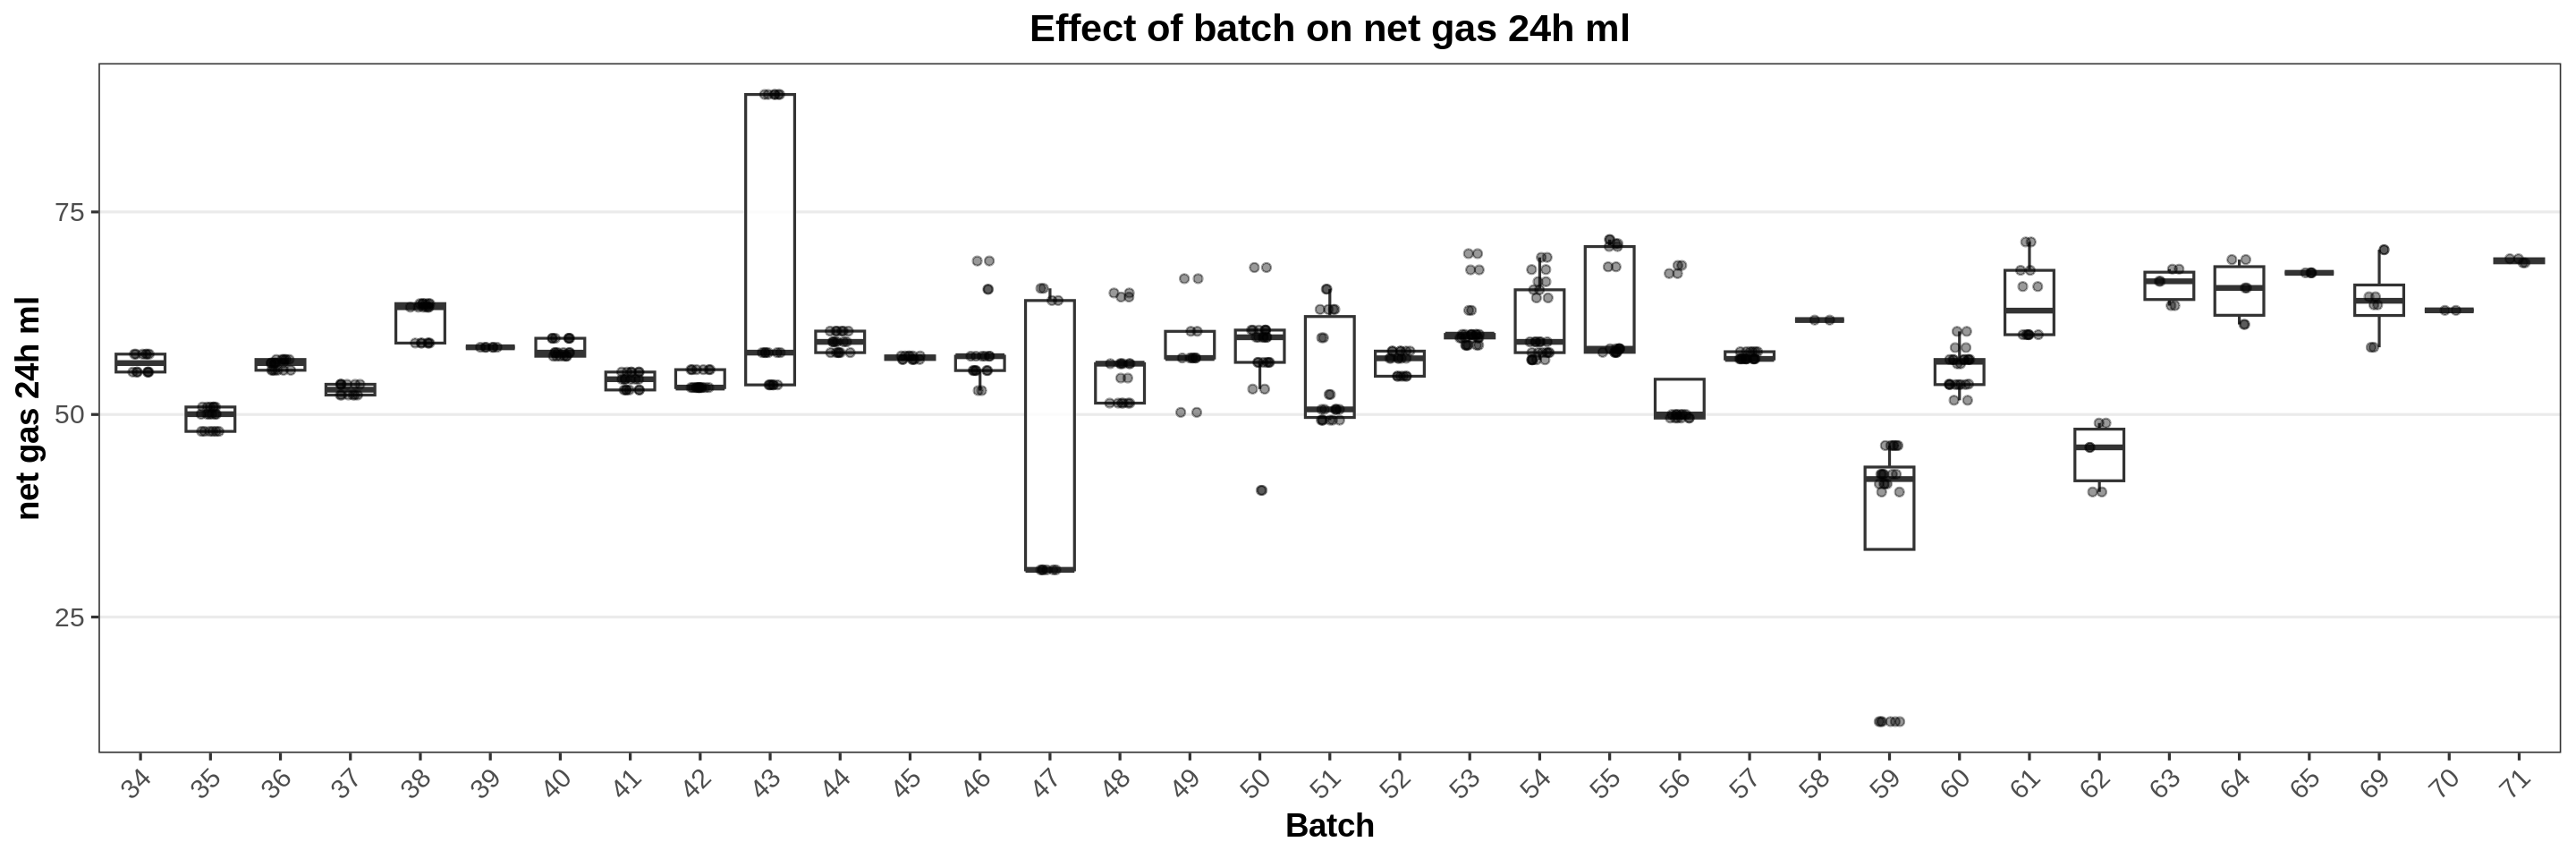

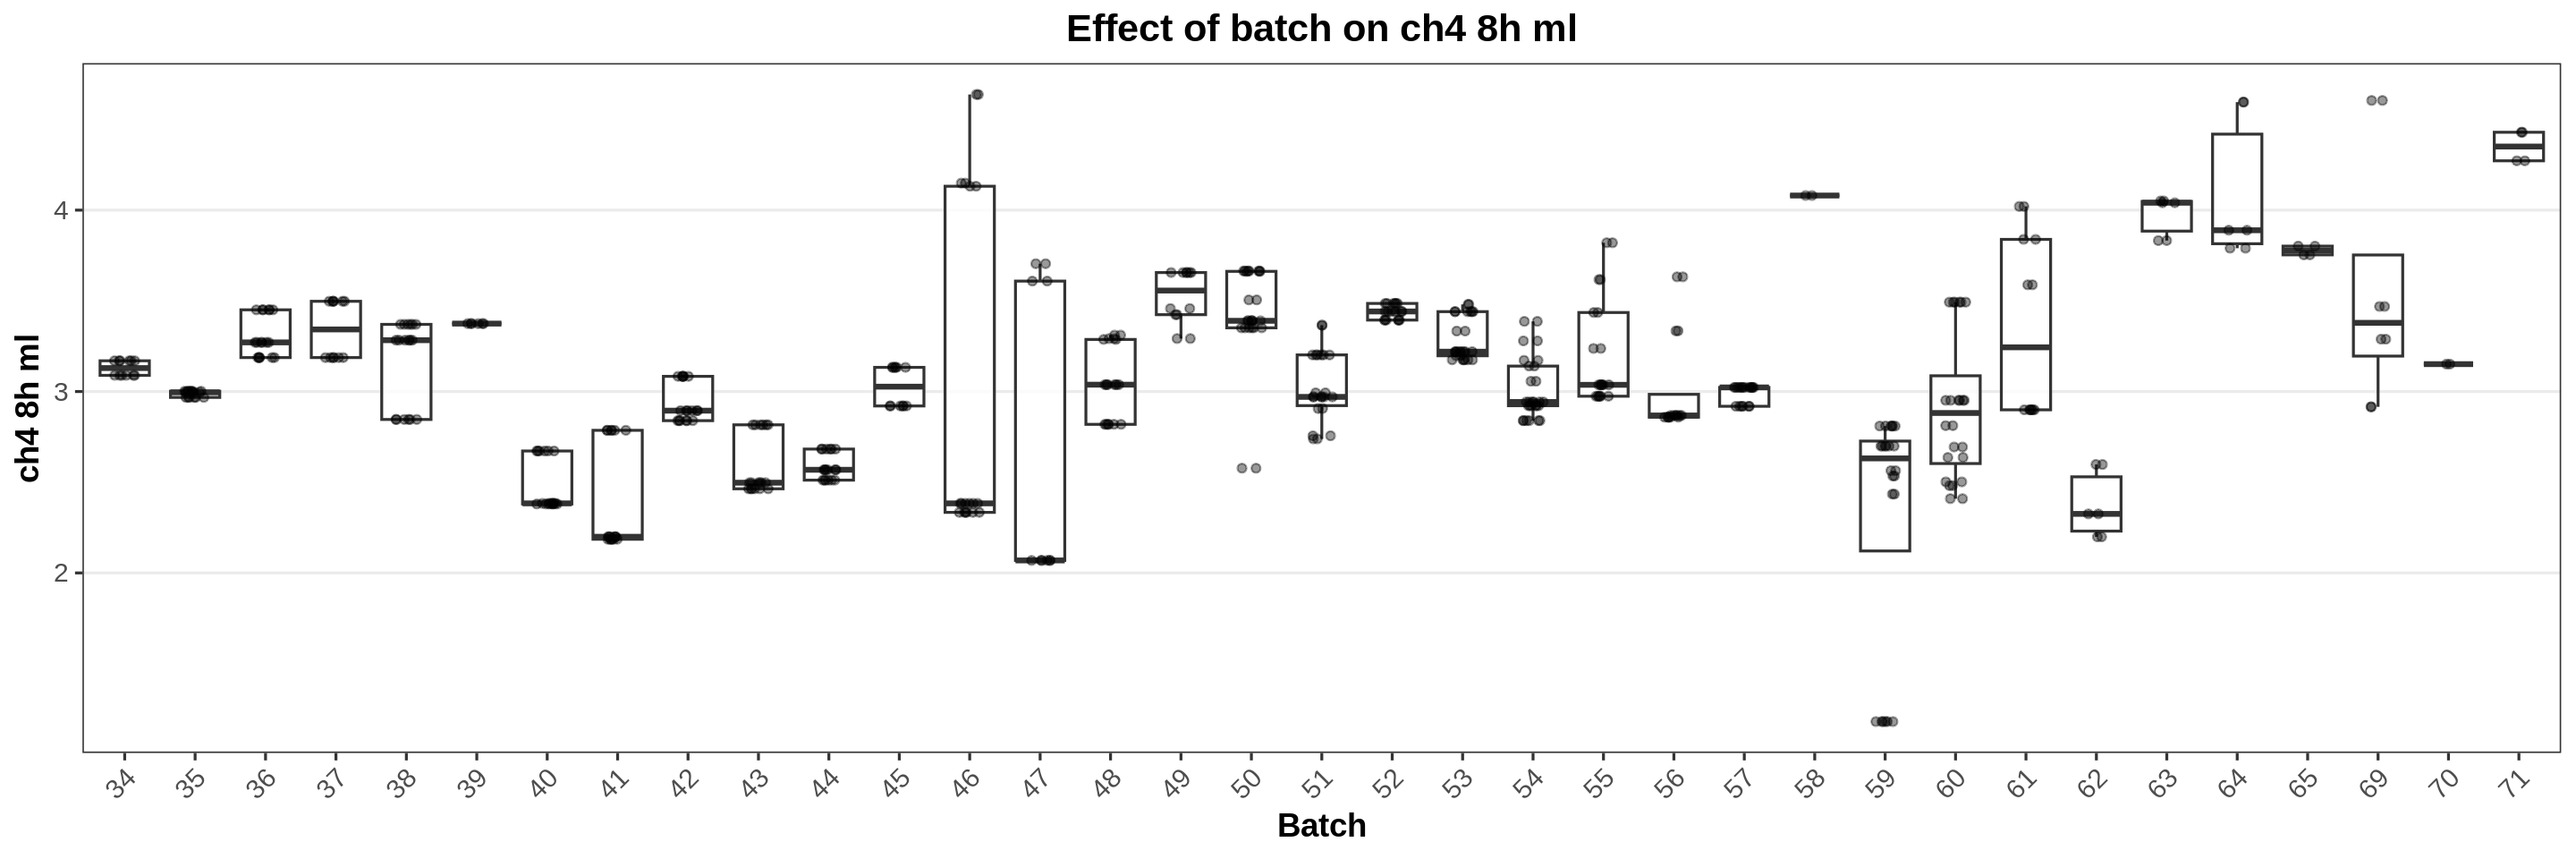

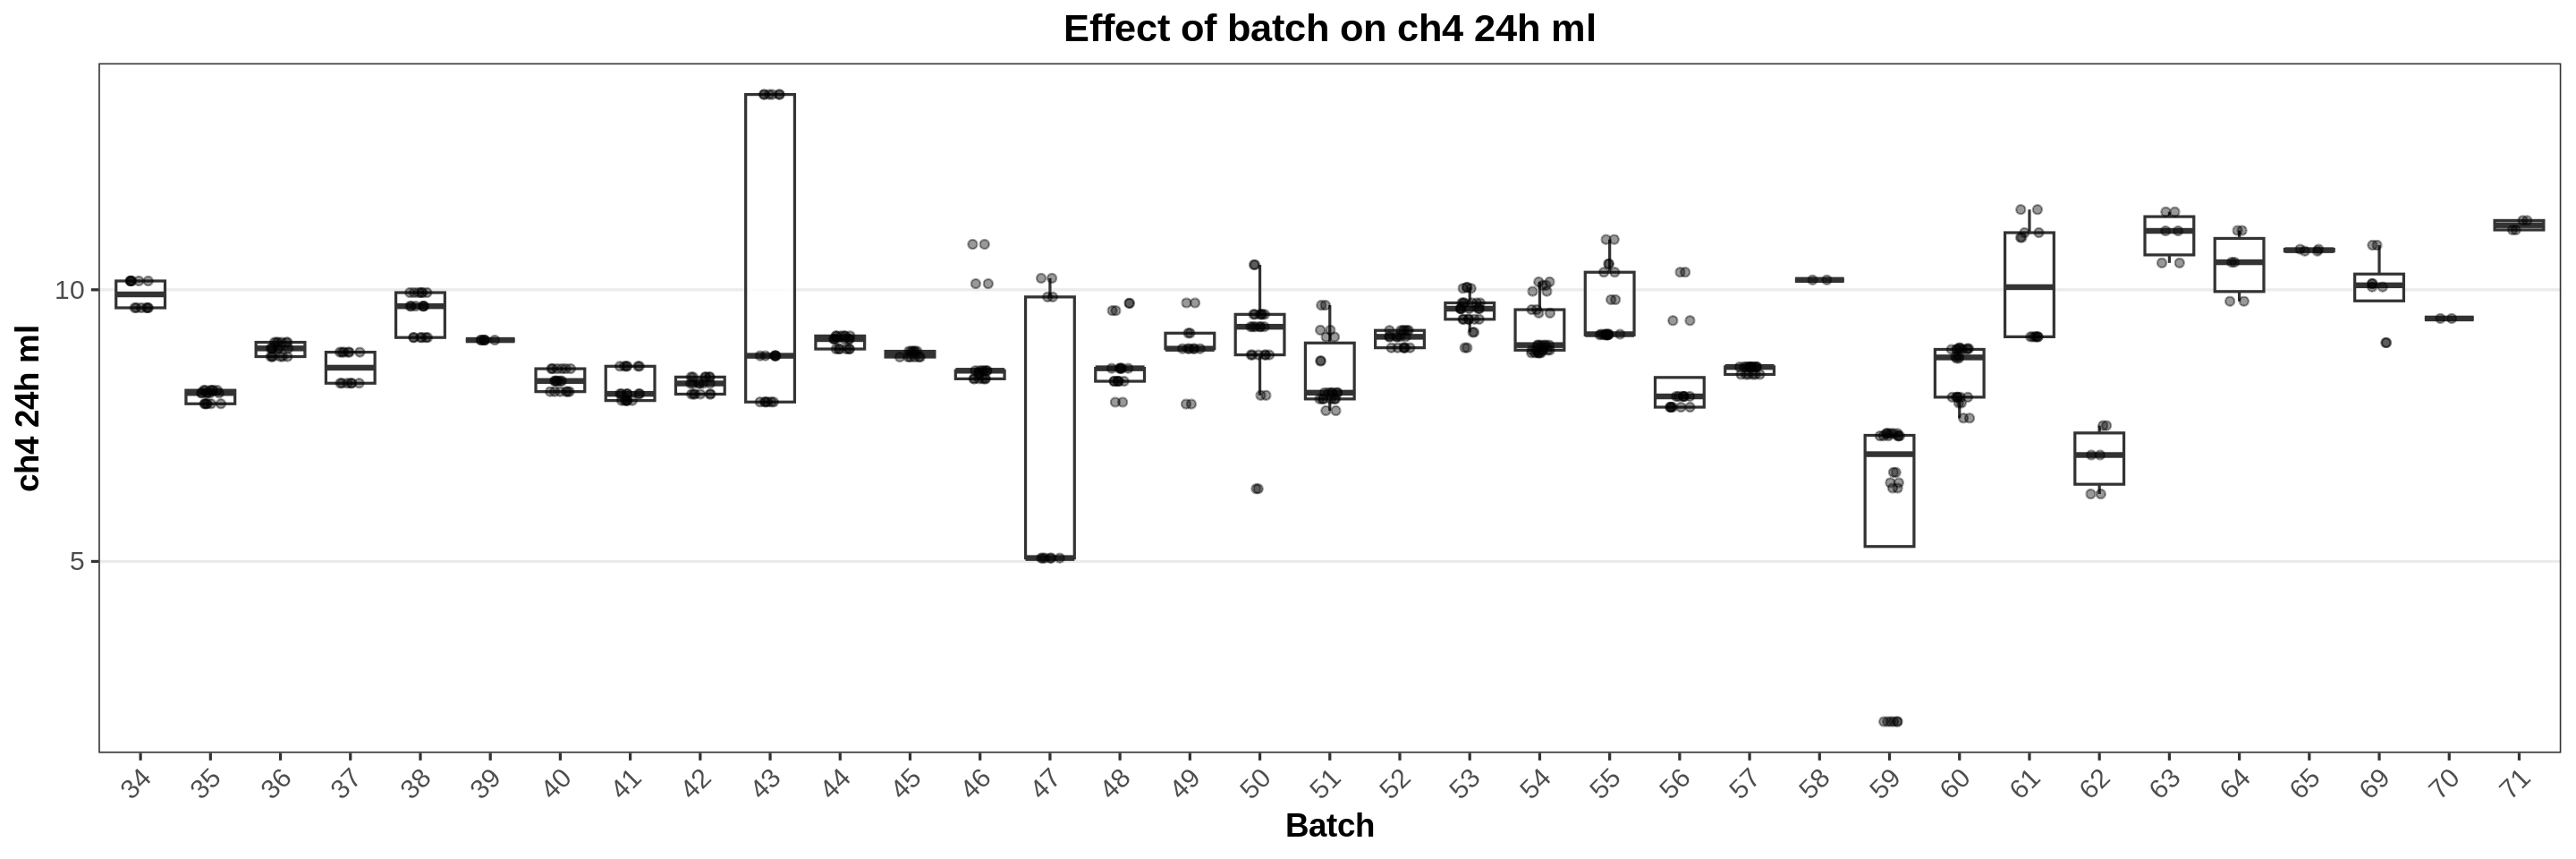

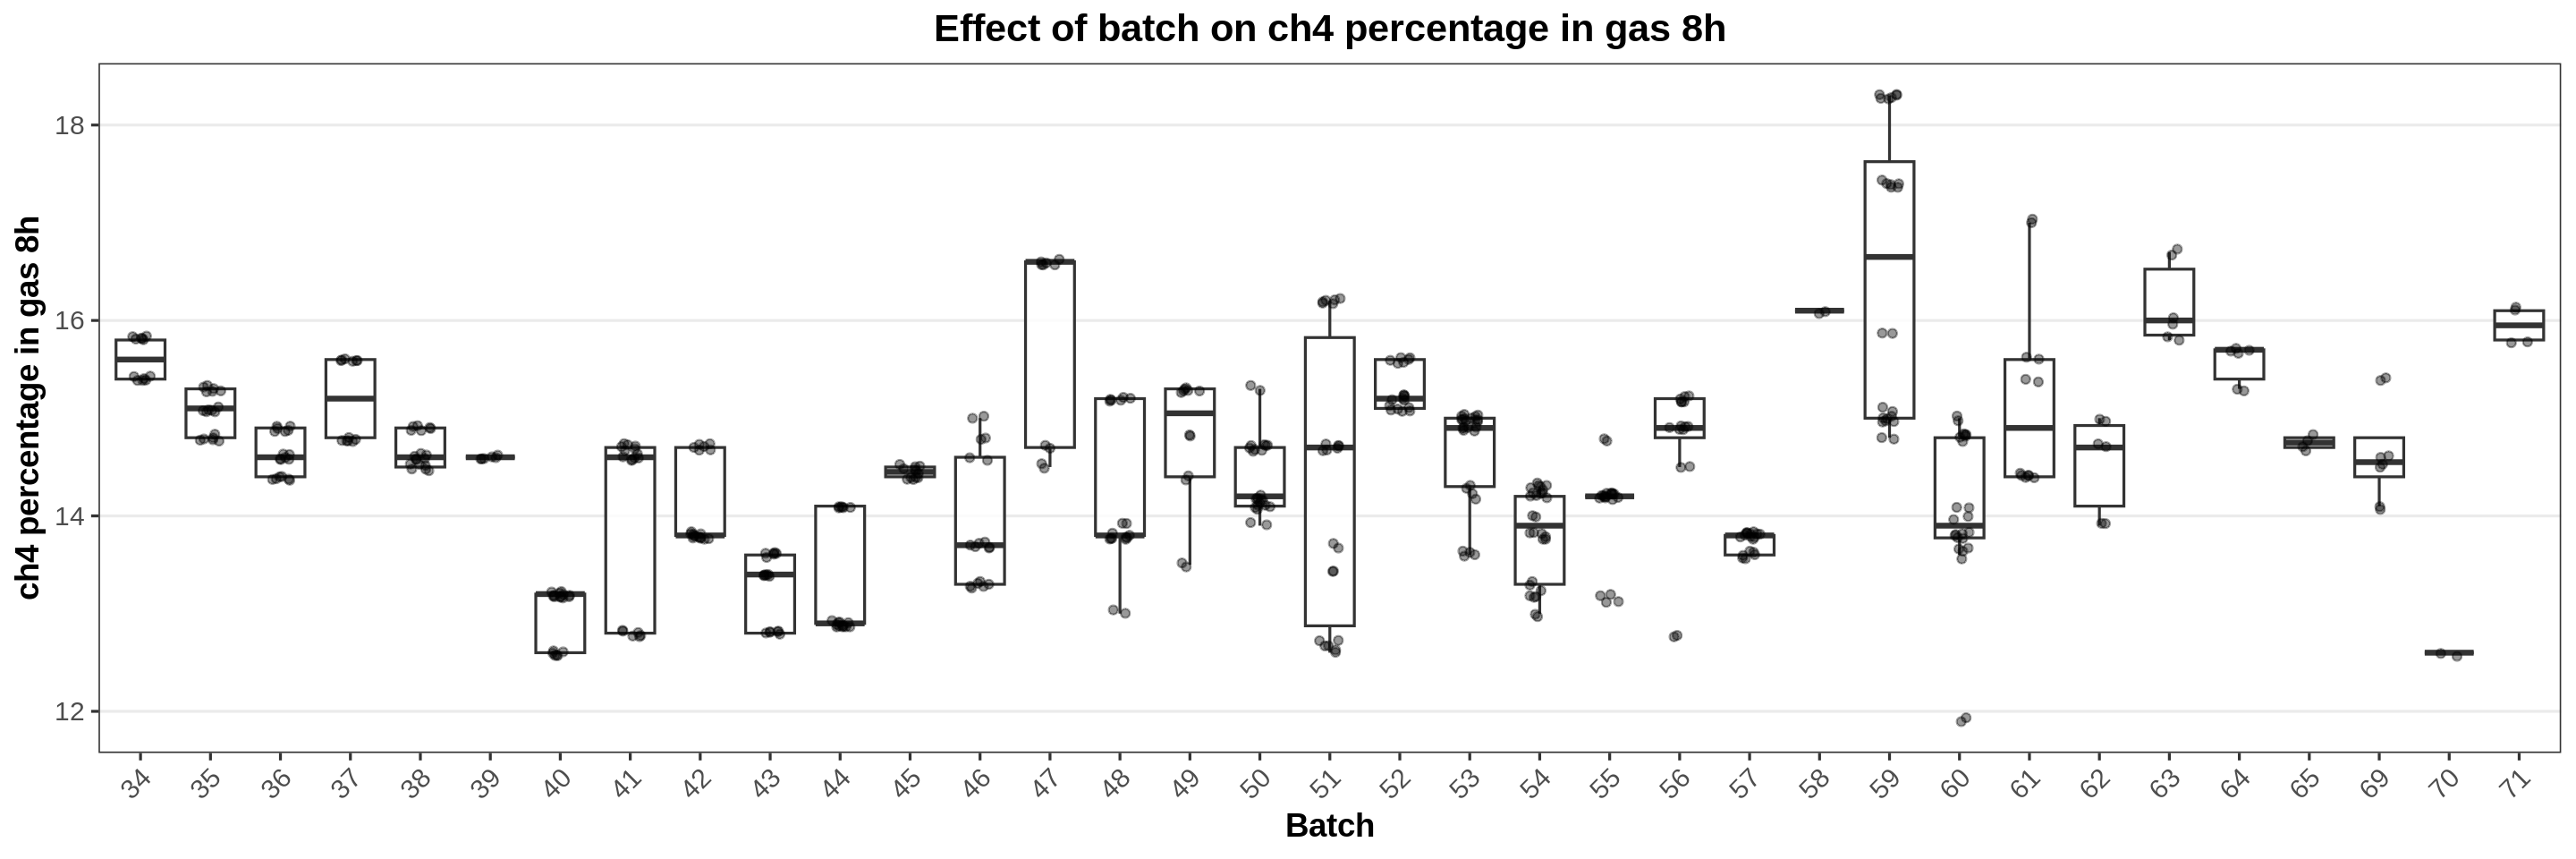

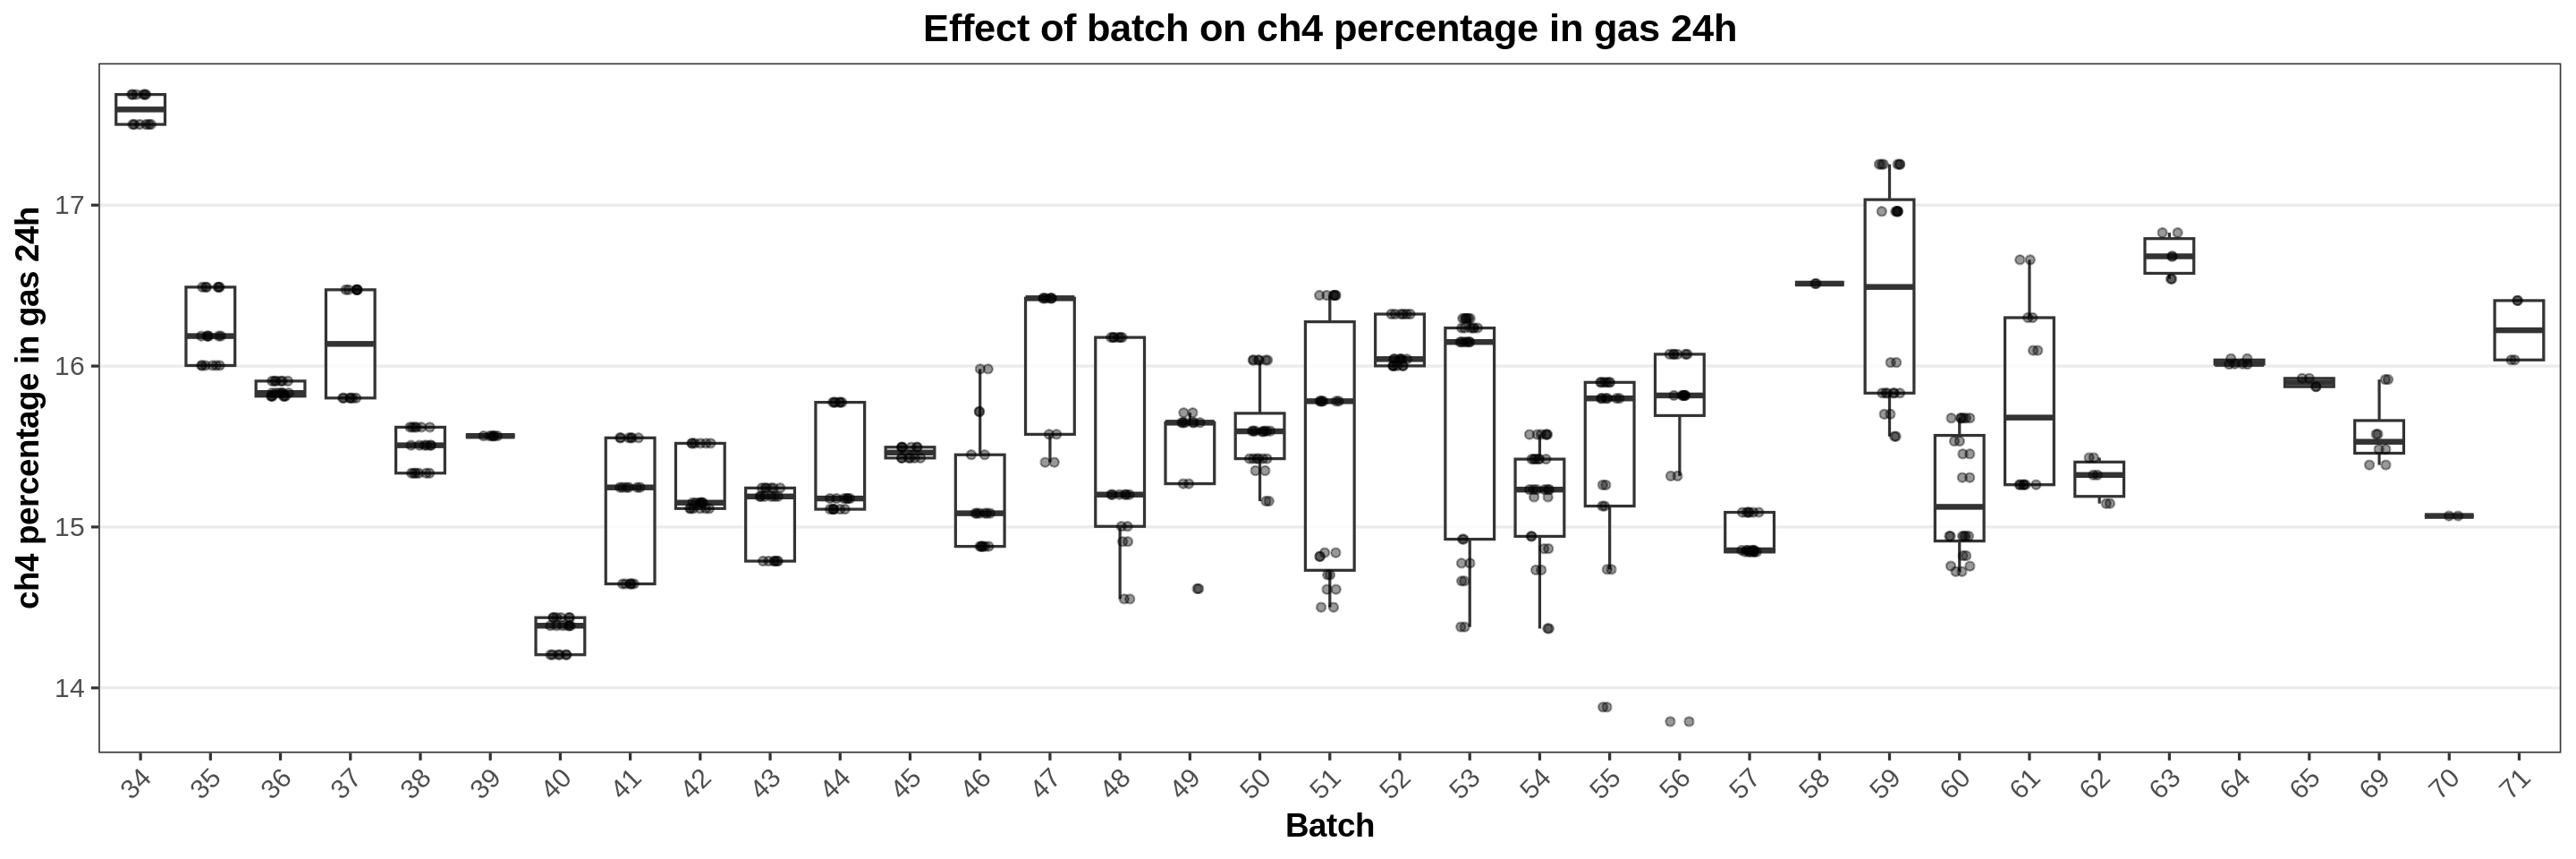

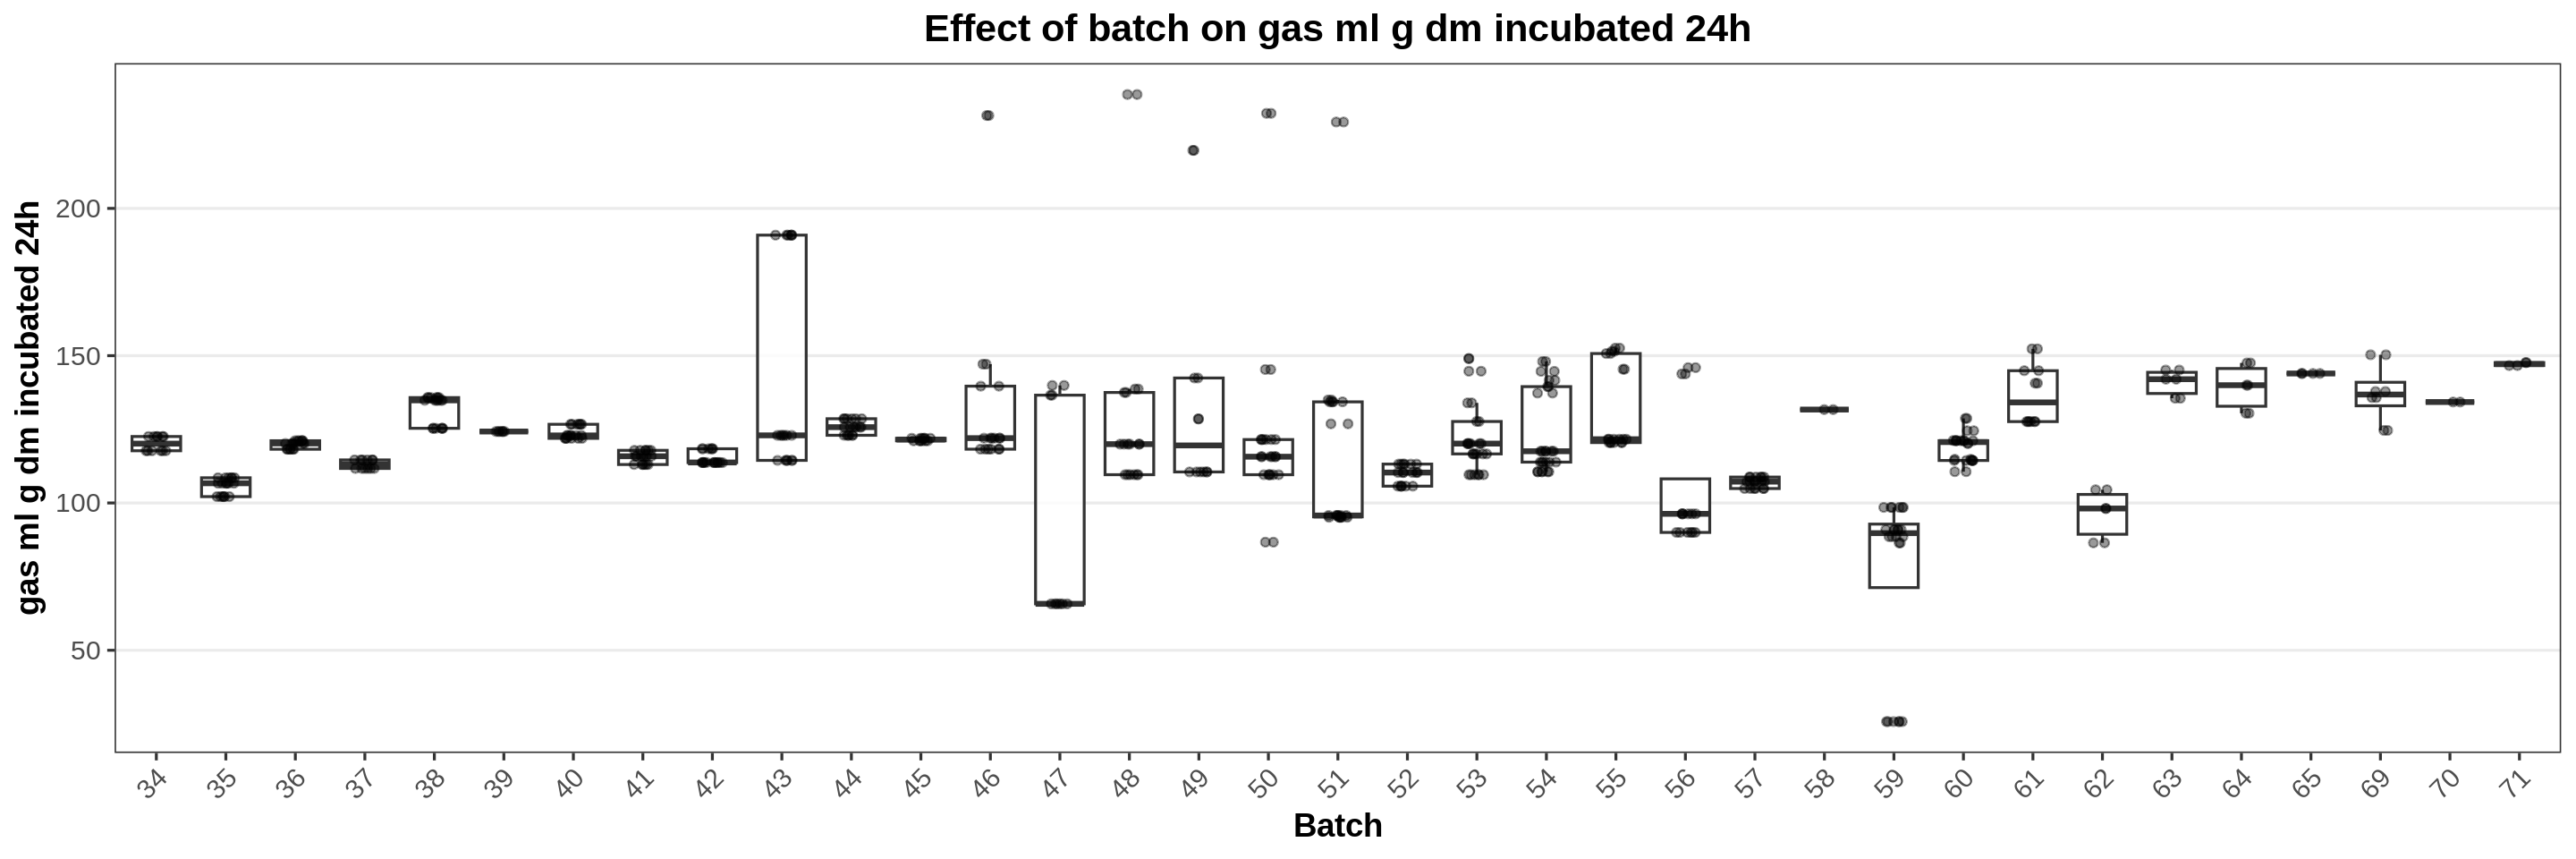

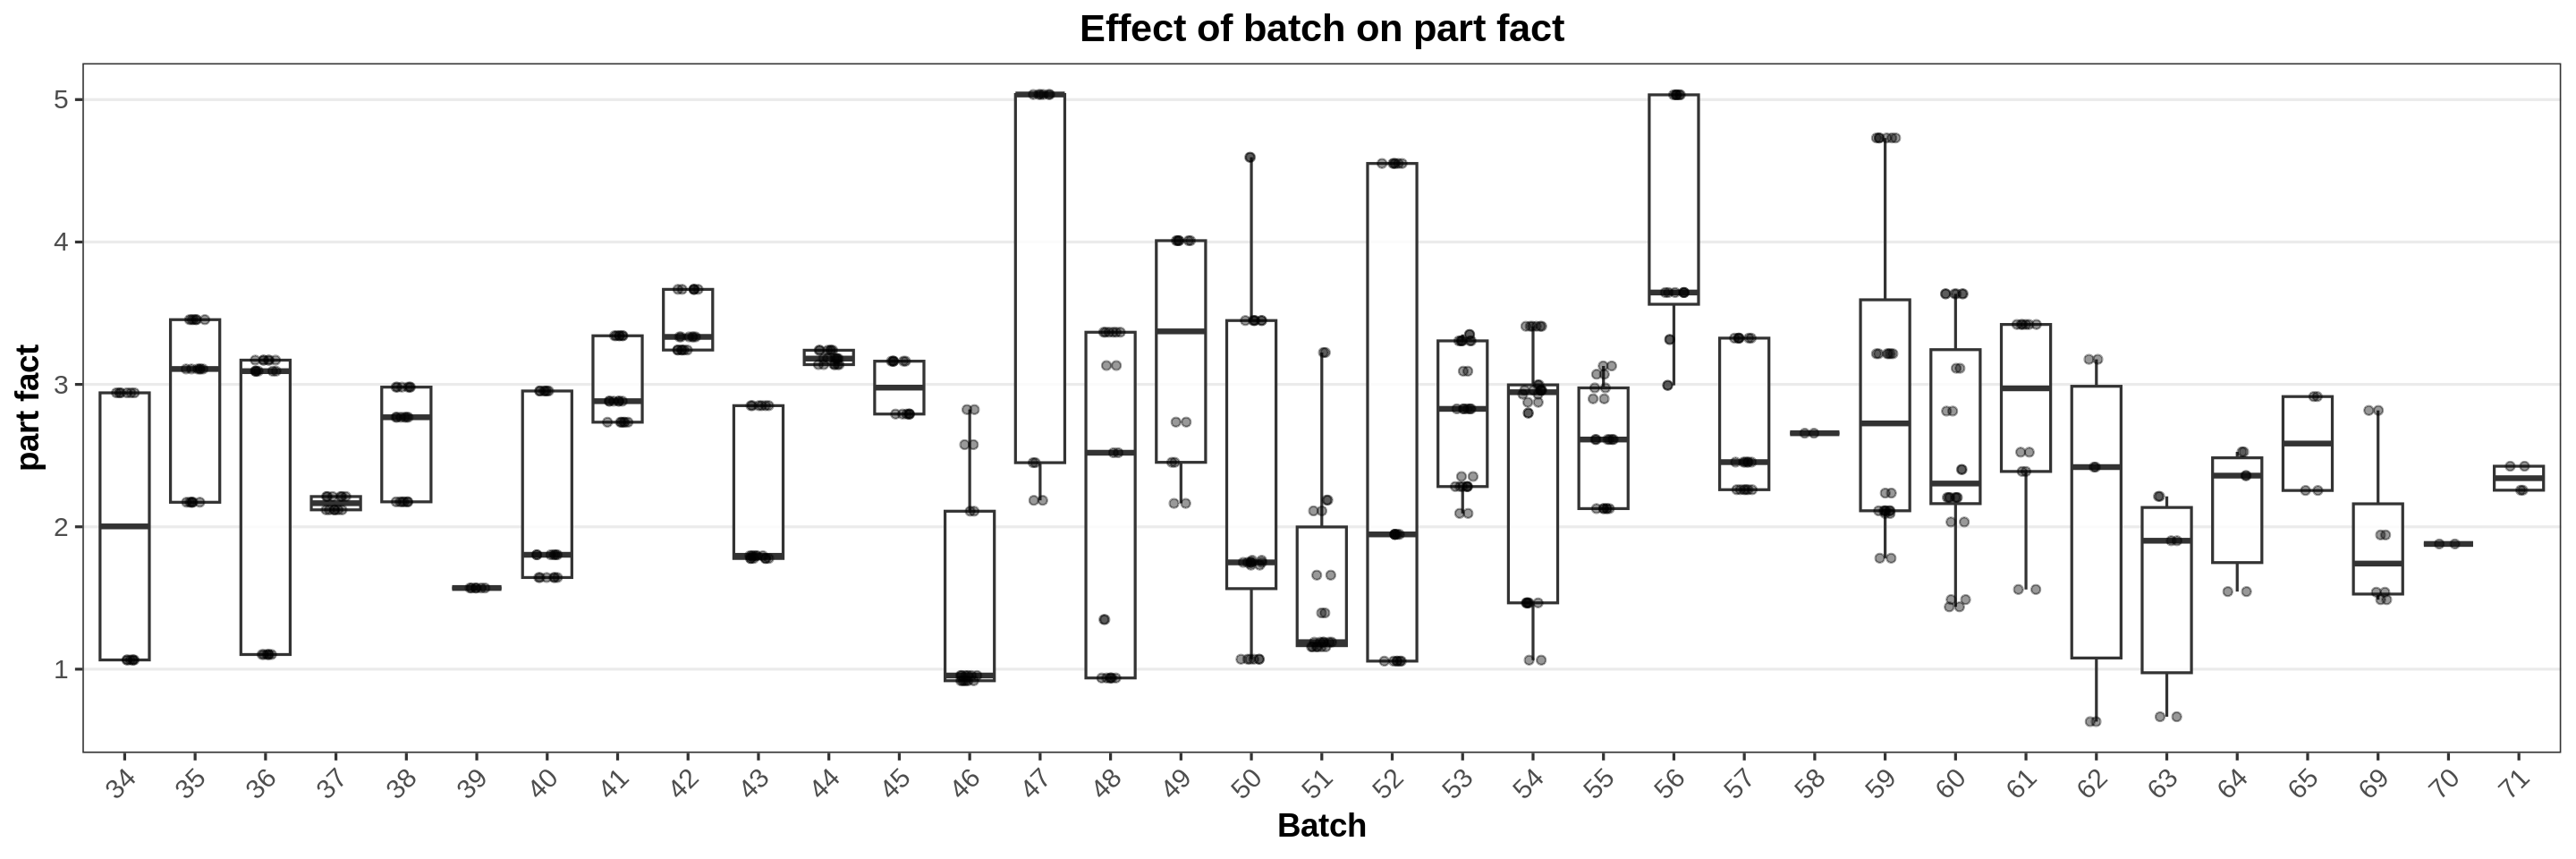

Warning message:
“Removed 54 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 54 rows containing missing values or values outside the scale range
(`geom_point()`).”


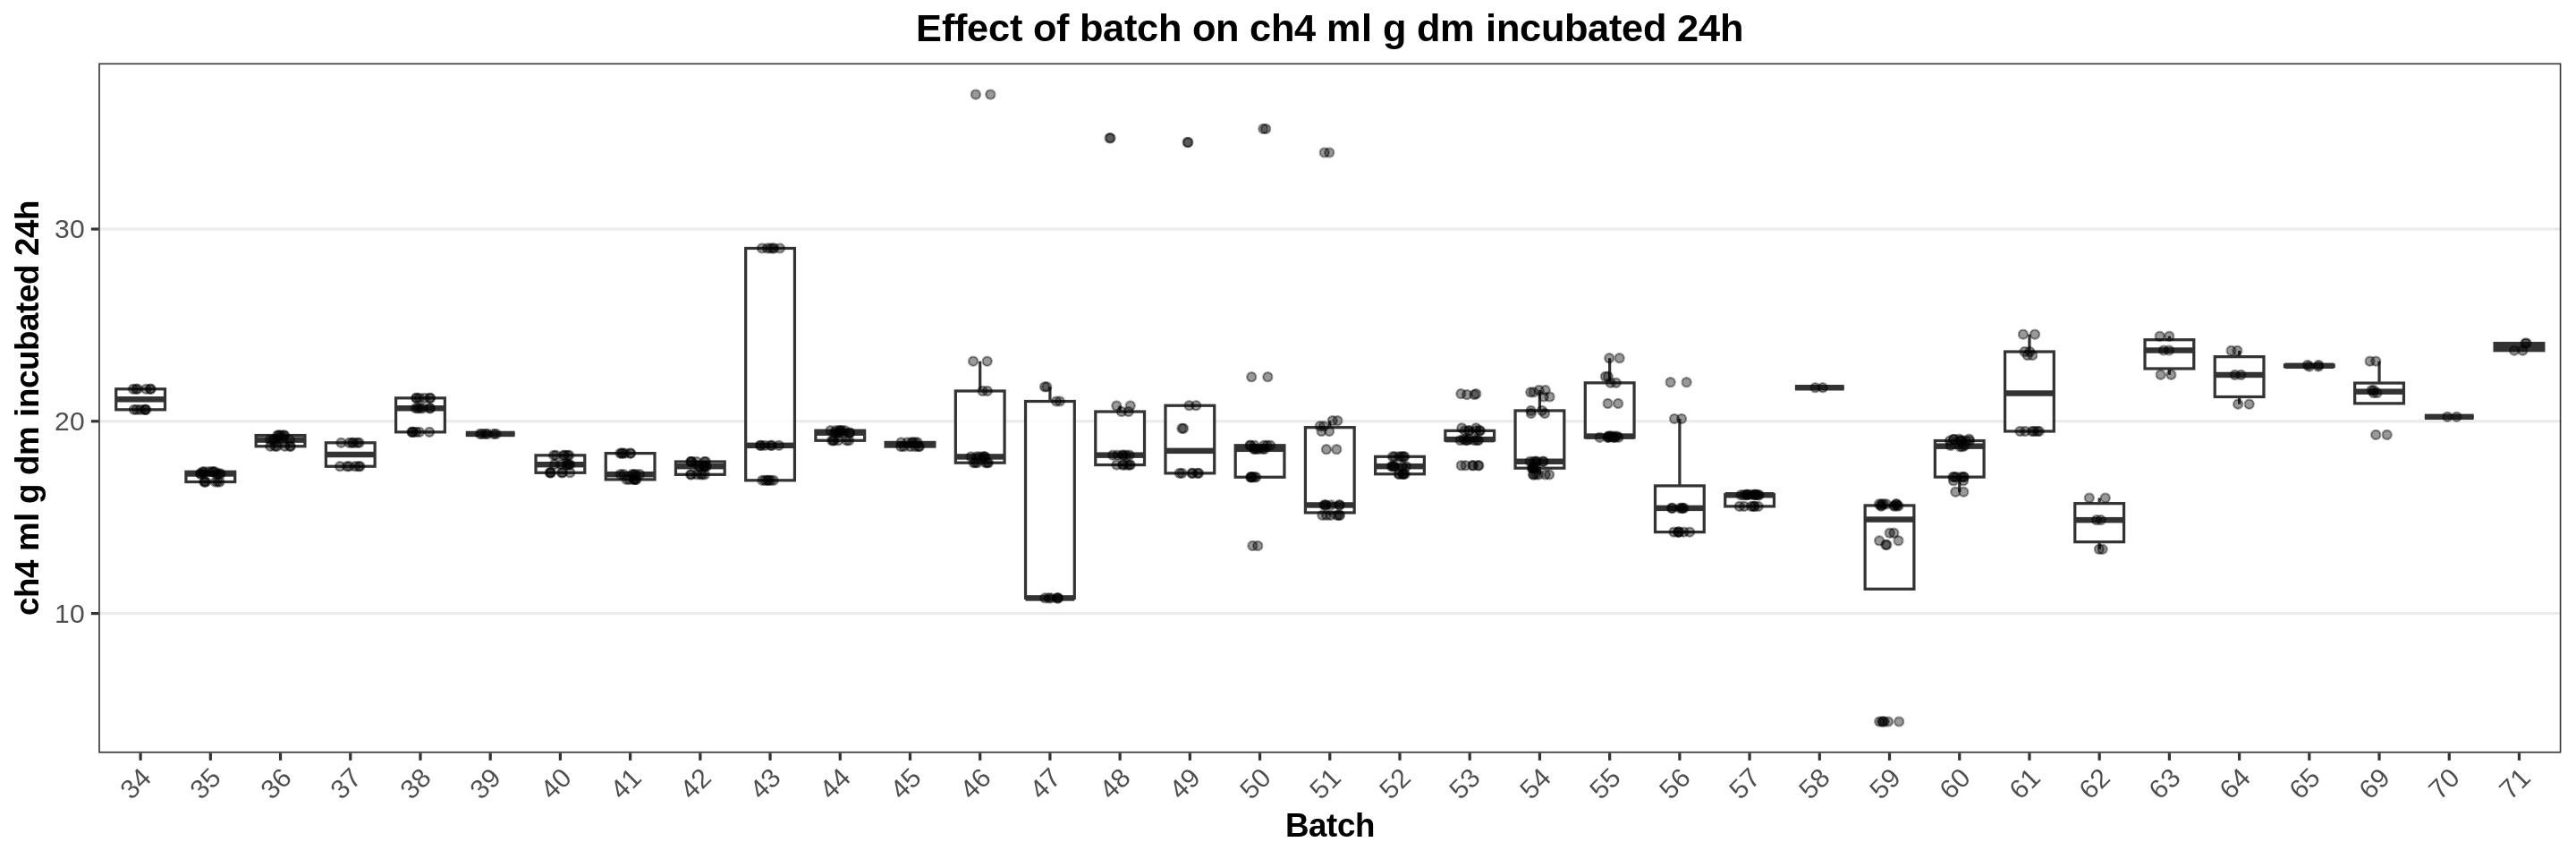

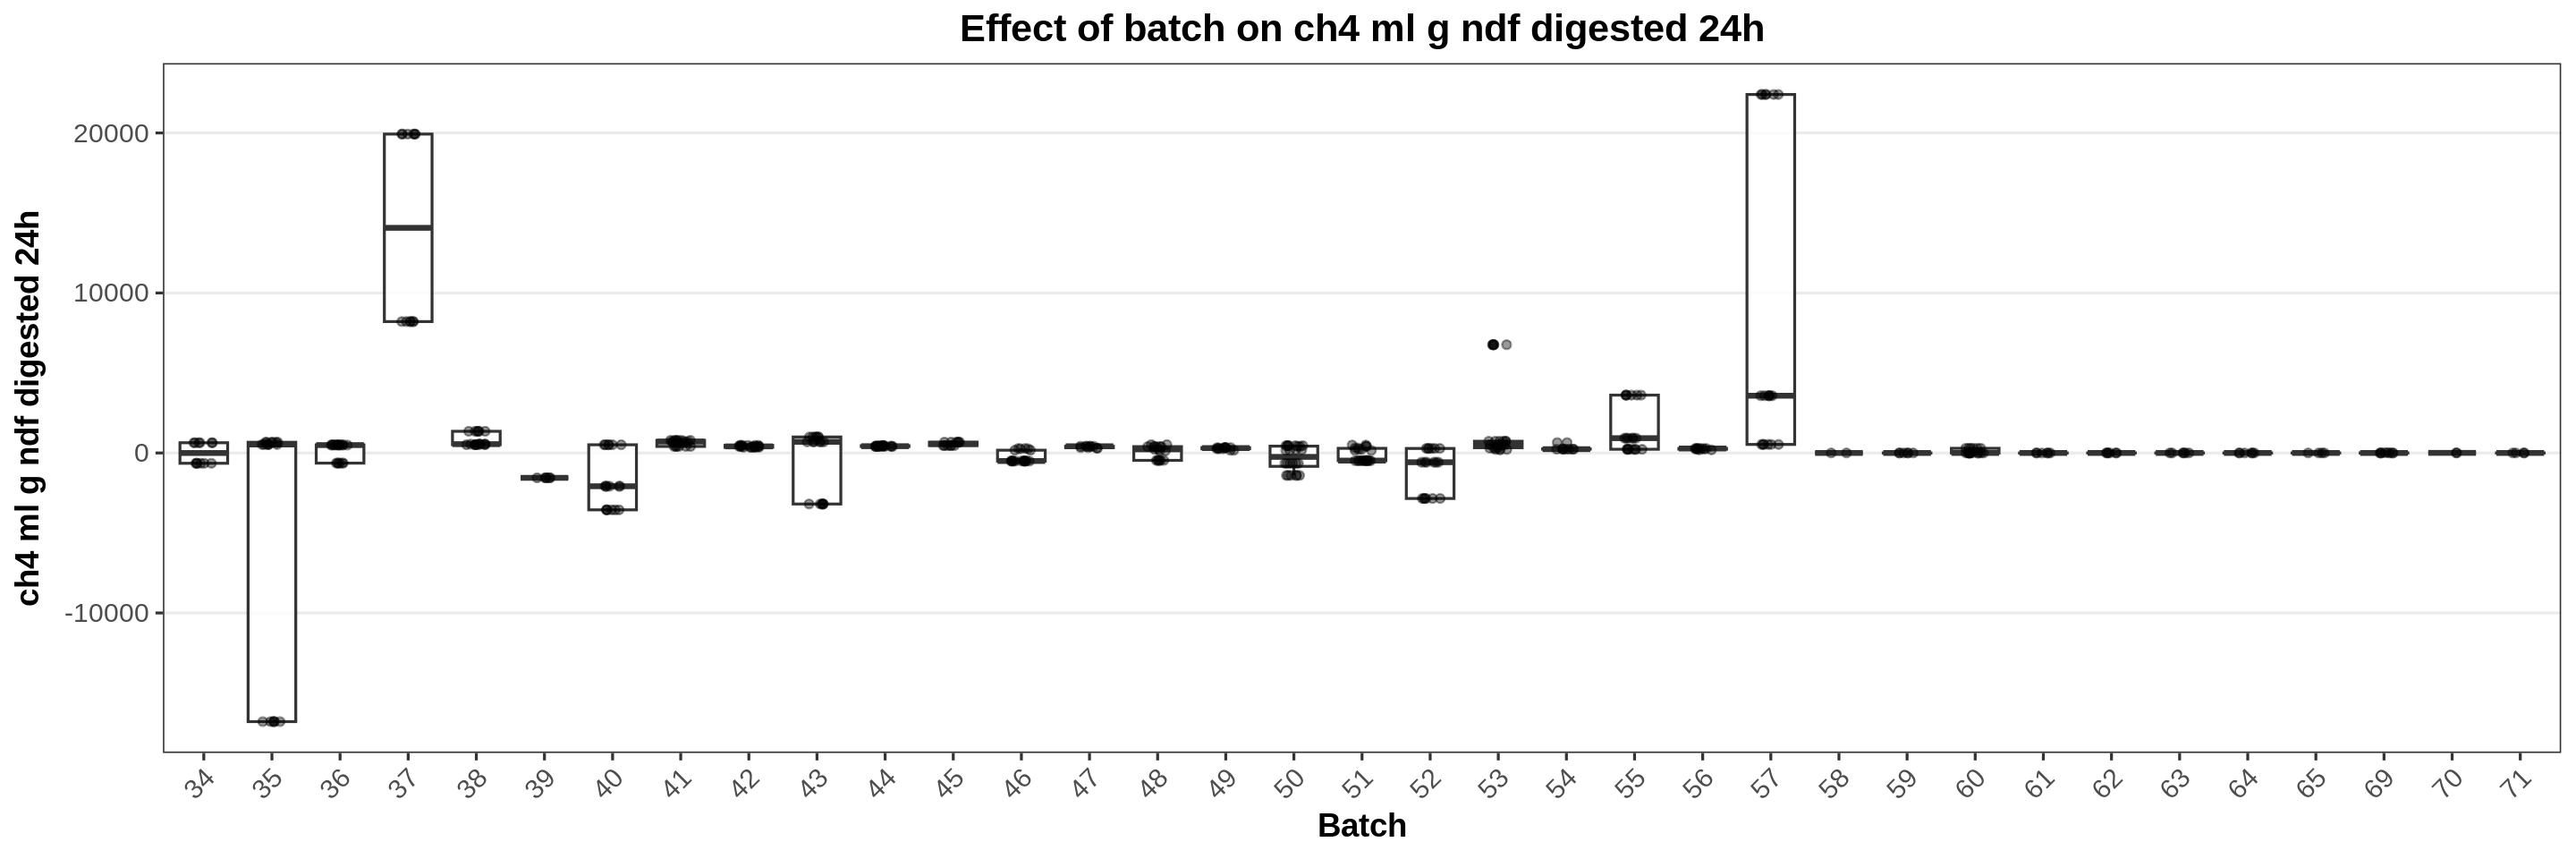

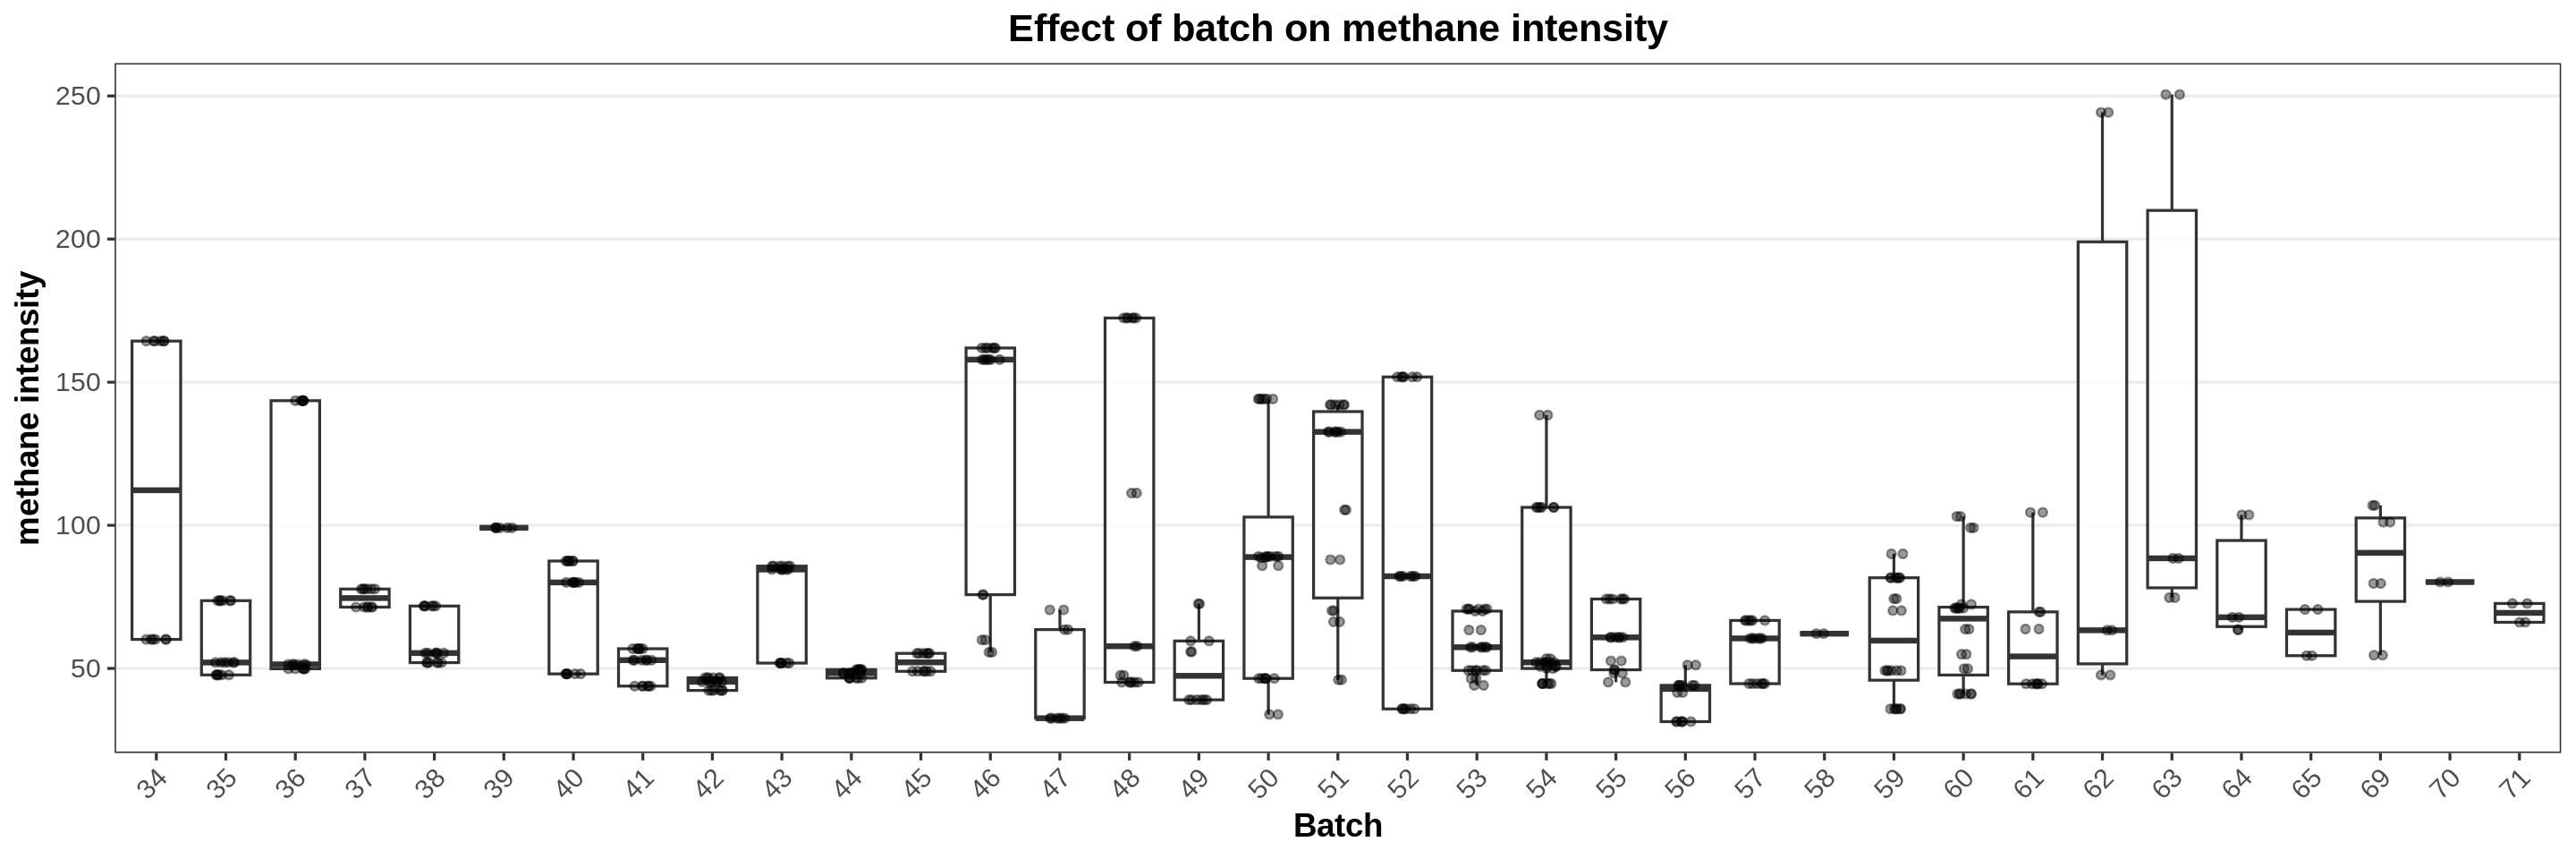

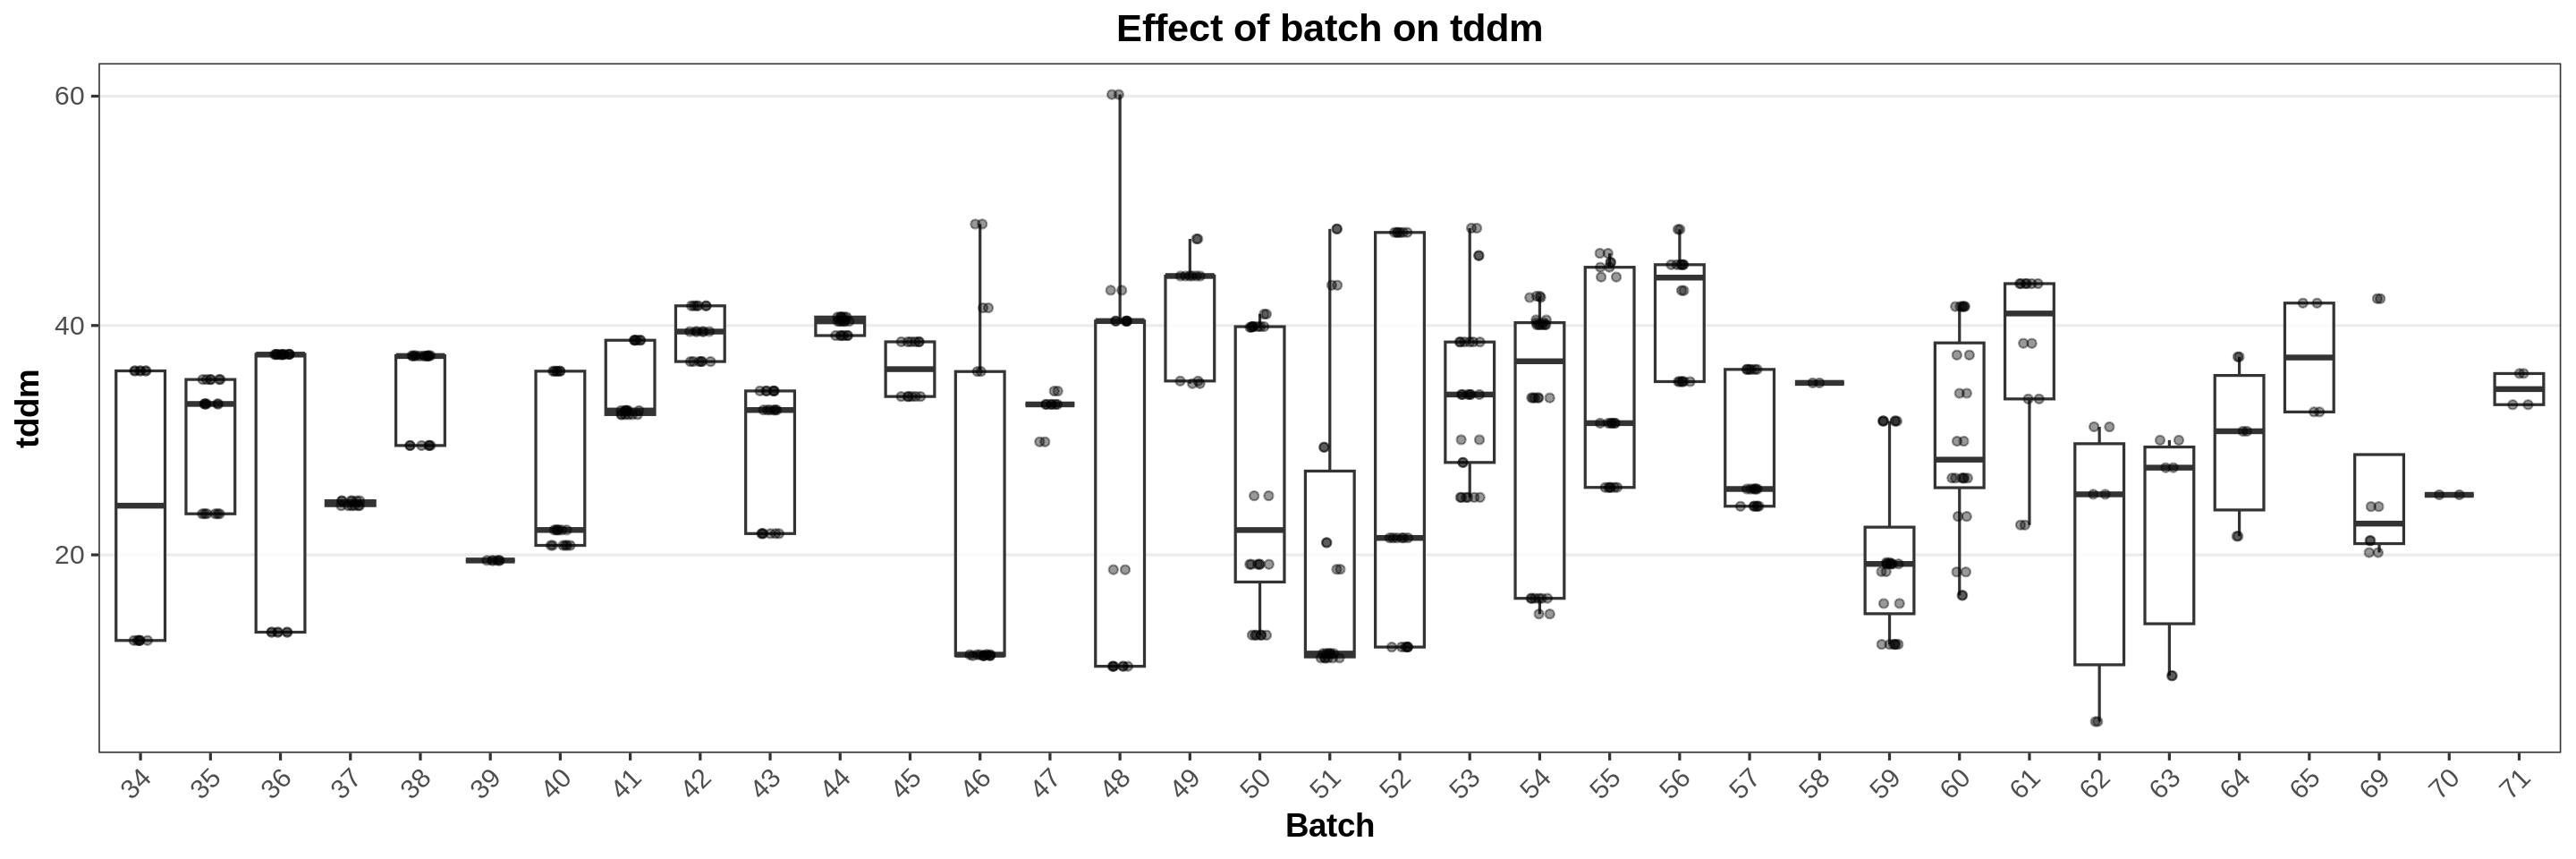

In [20]:
# Boxplot for all quantitative variables
options(repr.plot.width = 24, repr.plot.height = 8)

for (v in variables) {
  print(plot_batch_boxplot(star_grass, v))
}

In [21]:


plot_batch_boxplot <- function(data, variable) {

  #===========================
  # One-way ANOVA
  #===========================
  modelo <- lm(
    as.formula(paste(variable, "~ factor(batch)")),
    data = data
  )

  aov_tab <- anova(modelo)

  Fvalue <- round(aov_tab$`F value`[1], 2)
  pvalue <- aov_tab$`Pr(>F)`[1]

  p_label <- ifelse(
    pvalue < 0.001,
    "p < 0.001",
    paste0("p = ", signif(pvalue, 3))
  )

  #===========================
  # Plot
  #===========================
  ggplot(
    data,
    aes(
      x = factor(batch),
      y = .data[[variable]],
      fill = factor(batch)
    )
  ) +

    geom_boxplot(
      width = 0.70,
      alpha = 0.85,
      colour = "grey30",
      linewidth = 0.6,
      outlier.shape = NA
    ) +

    geom_jitter(
      width = 0.15,
      size = 2,
      alpha = 0.45,
      colour = "black"
    ) +

    # Soft pastel viridis colors
    scale_fill_viridis_d(
      option = "mako",
      begin = 0.20,
      end = 0.90
    ) +

    labs(
      x = "Batch",
      y = gsub("_", " ", variable),
      title = paste(
        "Effect of batch on",
        gsub("_", " ", variable)
      )
    ) +

    annotate(
      "text",
      x = Inf,
      y = Inf,
      hjust = 1.05,
      vjust = 1.4,
      size = 6,
      fontface = "bold",
      label = paste0(
        "ANOVA  ",
        "F = ", Fvalue,
        "\n",
        p_label
      )
    ) +

    theme_bw(base_size = 20) +

    theme(

      legend.position = "none",

      plot.title = element_text(
        size = 26,
        face = "bold",
        hjust = 0.5
      ),

      axis.title = element_text(
        size = 22,
        face = "bold"
      ),

      axis.text.x = element_text(
        size = 18,
        angle = 45,
        hjust = 1
      ),

      axis.text.y = element_text(
        size = 18
      ),

      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank()
    )

}

In [22]:
# Boxplot for all quantitative variables
options(repr.plot.width = 24, repr.plot.height = 8)

for (v in variables) {
  print(plot_batch_boxplot(star_grass, v))
}

Output hidden; open in https://colab.research.google.com to view.

### 4.3 BLUEs estimation